In [1571]:
"""
SED_plotting was getting too full so I added some plots here. 
Using the results from ProSpect, filtered for which model best fits each galaxy,
I plot time evolution (with redshift) for SED properties and morphology properties.
Plotting morphological results from all_morphology tables is executed here also.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit, minimize
import astropy.units as u
from astropy.io import fits
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
from IPython.display import display, Math
import math
import emcee
import corner

SERSIC_FILTERS = ["F444W", "F356W", "F277W"]

In [1572]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [1573]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return red_chi

In [1574]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params,
                                  x_obs=None, x_err_low=None, x_err_high=None,
                                  gradient=None):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties,
    optionally including x uncertainties projected onto y via the model gradient.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    y_model : array_like
        Model predictions.
    n_params : int
        Number of fitted parameters.
    x_obs : array_like, optional
        Observed x values. Required if x_err_low/x_err_high are given.
    x_err_low : array_like, optional
        Lower (negative) uncertainties on x. If None, treated as zero.
    x_err_high : array_like, optional
        Upper (positive) uncertainties on x. If None, treated as zero.
    gradient : float, optional
        Local gradient of the model (dy/dx), used to project x uncertainty
        onto y. Required if x uncertainties are non-zero.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs, dtype=float)
    y_model = np.asarray(y_model, dtype=float)
    y_err_low = np.asarray(y_err_low, dtype=float)
    y_err_high = np.asarray(y_err_high, dtype=float)

    # Use the appropriate uncertainty depending on which side of the data
    sigma_y = np.where(y_model > y_obs, y_err_high, y_err_low)

    # Handle x uncertainties, if provided
    if x_err_low is None:
        x_err_low = np.zeros_like(y_obs)
    else:
        x_err_low = np.asarray(x_err_low, dtype=float)

    if x_err_high is None:
        x_err_high = np.zeros_like(y_obs)
    else:
        x_err_high = np.asarray(x_err_high, dtype=float)

    # If x errors are all zero, skip the x-error projection entirely —
    # this avoids requiring x_obs/gradient when there's nothing to project
    if np.all(x_err_low == 0) and np.all(x_err_high == 0):
        sigma = sigma_y
    else:
        if x_obs is None or gradient is None:
            raise ValueError("x_obs and gradient must be provided when x uncertainties are non-zero.")

        x_obs = np.asarray(x_obs, dtype=float)
        sigma_x = np.where(y_model > y_obs, x_err_high, x_err_low)

        # project x uncertainty onto y using the model gradient, combine in quadrature
        sigma = np.sqrt(sigma_y**2 + (gradient * sigma_x)**2)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [1575]:
def calculate_nmad(y, y_err_high, y_err_low, y_model, x_err_high, x_err_low, gradient, int_scatter):
    """
    Calculates the residuals between linear model and observed data.
    Normalises residuals by error.
    Calculates NMAD.
    """
    residuals = y - y_model

    y_sigma = np.where(
        residuals > 0,
        y_err_low,   # data lie above model
        y_err_high   # data lie below model
    )

    if x_err_high is None or x_err_low is None or gradient is None:
        x_err_high = np.zeros_like(y)
        x_err_low = np.zeros_like(y)
        gradient = 0.0

    if int_scatter is None:
        int_scatter = 0.0
    
    if gradient >= 0:
        x_sig = np.where(residuals >= 0, x_err_high, x_err_low)
        # If residual is positive and slope is positive, use upper x error
    else:
        x_sig = np.where(residuals >= 0, x_err_low, x_err_high)
        # if residual is negative and slope is negative, use upper x error.
        # if residual is positive and slope is negative, use lower x error.

    total_sigma = np.sqrt(y_sigma**2 + (gradient * x_sig)**2 + int_scatter**2)

    normalised_residuals = residuals / total_sigma

    nmad = 1.4826 * np.median( np.abs( normalised_residuals - np.median(normalised_residuals) ) )
    return nmad

In [1576]:
def uncertainty_propagation(parameters, equation, n_samples=2000, batch_size=500):
    """
    Bootstrap-based uncertainty propagation.

    Parameters
    ----------
    parameters : list of tuples
        Each element is (Q16, Q50, Q84) for a parameter.
    equation : callable
        Function that accepts arrays of sampled parameters.
    n_samples : int
        Number of Monte Carlo samples.
    batch_size : int
        Number of samples to evaluate at once.

    Returns
    -------
    med : float
        Median of propagated quantity.
    upper_err : float
        +1 sigma (84th - median)
    lower_err : float
        -1 sigma (median - 16th)
    """

    samples = []
    # Stores Monte Carlo samples for each parameter

    # Bootstrap each parameter from its empirical percentiles
    for (q16, q50, q84) in parameters:

        # construct empirical distribution (no shape assumptions)
        x = np.array([q16, q50, q84]) # what the percentile values are
        p = np.array([0.16, 0.50, 0.84]) # defines the values as the percentiles we know them to be

        # bootstrap sampling via inverse CDF interpolation
        u = np.random.rand(n_samples) # Random percentiles of 0s and 1s
        s = np.interp(u, p, x) # Takes random percentile and interpolates with known quantities and returns the interpolated value

        samples.append(s)

    # shape: (n_params, n_samples)
    samples = np.array(samples) # converts list into array

    # transpose → (n_samples, n_params)
    samples = samples.T # now each row is (param1_i, param2_i,...)

    # Evaluate model in batches
    values = []

    for start in range(0, n_samples, batch_size):

        stop = min(start + batch_size, n_samples)

        batch_samples = samples[start:stop]

        batch_values = equation(batch_samples) # rows of output_i = equation(param1_i, param2_i,...)

        values.append(batch_values)

    values = np.concatenate(values)

    # Return percentiles
    med = np.percentile(values, 50)
    low = np.percentile(values, 16)
    high = np.percentile(values, 84)

    # RMS scatter of the Monte Carlo distribution
    scatter = np.std(values, ddof=1)

    return med, high - med, med - low

In [1577]:
def format_value_uncertainty(value, upper_err, lower_err):
    """
    Format a value with asymmetric uncertainties using standard
    significant-figure rules (PDG rounding: 1 sig fig, or 2 if the
    leading digit is 1 or 2).

    Parameters
    ----------
    value : float
        Central value.
    upper_err : float
        +1 sigma uncertainty.
    lower_err : float
        -1 sigma uncertainty.

    Returns
    -------
    value_str, upper_str, lower_str : str
        Formatted value and uncertainties, all rounded to a consistent
        number of decimal places.
    """

    if upper_err == 0 and lower_err == 0:
        return f"{value:.3f}", "0", "0"

    def get_decimals(err):
        if err == 0:
            return 0
        exponent = math.floor(math.log10(abs(err)))
        first_digit = int(abs(err) / 10**exponent)
        sig_figs = 2 if first_digit in [1, 2] else 1
        return -(exponent - (sig_figs - 1))

    # decide precision using whichever error needs more decimal places,
    # so neither error gets rounded away to zero
    decimals = max(get_decimals(upper_err), get_decimals(lower_err))

    value_rounded = round(value, decimals)
    upper_rounded = round(upper_err, decimals)
    lower_rounded = round(lower_err, decimals)

    fmt = f"{{:.{max(decimals, 0)}f}}"

    return fmt.format(value_rounded), fmt.format(upper_rounded), fmt.format(lower_rounded)

In [1578]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl

In [1579]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    # print("Table headers: ", table.colnames)
    
    """
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumQ50","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    """
    return table

In [1580]:
def _parse_err(err, n):
    """
    Normalize an error specification into (err_lo, err_hi) arrays of length n.

    Accepted forms for `err`:
      - None                            -> zeros (no error)
      - scalar or 1D array of length n  -> symmetric error (same as before)
      - [err_high, err_low]             -> asymmetric error; each of
        err_high/err_low can be a scalar (applied to all points) or a
        length-n array (per-point)

    Returned lo/hi are positive distances from the central value
    (lower bound = value - lo, upper bound = value + hi).
    """
    if err is None:
        return np.zeros(n), np.zeros(n)

    # Asymmetric: [err_high, err_low]
    if isinstance(err, (list, tuple)) and len(err) == 2:
        hi = np.asarray(err[0], dtype=float)
        lo = np.asarray(err[1], dtype=float)
        if hi.ndim == 0:
            hi = np.full(n, float(hi))
        if lo.ndim == 0:
            lo = np.full(n, float(lo))
        return lo.copy(), hi.copy()

    # Symmetric: scalar or array, same as before
    arr = np.asarray(err, dtype=float)
    if arr.ndim == 0:
        arr = np.full(n, float(arr))
    return arr.copy(), arr.copy()


def fit_linear_mcmc(x_in, y_in, x_err=None, y_err=None, x_pivot=None,
                     n_walkers=50, n_steps=10000, plot=False, save_path=None):
    """
    Bayesian linear fit y = m*(x - x_pivot) + c with intrinsic scatter,
    supporting asymmetric measurement errors in both x and y.

    x_err / y_err each accept:
      - None, a scalar, or a 1D array of length N (symmetric errors, same
        as before), OR
      - [err_high, err_low] for asymmetric errors, where each of
        err_high/err_low is a scalar (applied to every point) or a
        length-N array (per-point).

    Asymmetric-error handling
    --------------------------
    Each data point's error distribution is modeled as a split-normal
    (two-piece Gaussian): width `sigma_lo` below the measured value and
    `sigma_hi` above it. At every MCMC step, for each point we compare the
    model prediction to the data (delta = model - data) and pick the
    error side consistent with that comparison:
        delta >= 0  ->  use the "hi" error (model sits above the data)
        delta <  0  ->  use the "lo" error (model sits below the data)
    This is applied to both the y errors and the x errors (the latter
    projected into y-space via the slope, m^2 * xerr^2, as in the
    symmetric case). This is the standard practical approximation for
    asymmetric errors in a likelihood — it is exact only when the true
    error distribution really is split-normal, but works well in general
    and reduces to the ordinary symmetric-error likelihood when lo == hi.
    The intrinsic scatter term sigma_int is kept symmetric.
    """
    # --- Step 1: Data Cleaning & Pivot Handling ---
    x = np.asarray(x_in, dtype=float)
    y = np.asarray(y_in, dtype=float)
    n = len(x)

    xe_lo, xe_hi = _parse_err(x_err, n)
    ye_lo, ye_hi = _parse_err(y_err, n)

    xp = 0.0 if x_pivot is None else x_pivot

    mask = (
        np.isfinite(x) & np.isfinite(y)
        & np.isfinite(xe_lo) & np.isfinite(xe_hi)
        & np.isfinite(ye_lo) & np.isfinite(ye_hi)
    )

    # Guard against zero/negative error entries (keeps likelihood well-defined)
    xe_lo = np.where(xe_lo <= 0, 1e-10, xe_lo)
    xe_hi = np.where(xe_hi <= 0, 1e-10, xe_hi)
    ye_lo = np.where(ye_lo <= 0, 1e-10, ye_lo)
    ye_hi = np.where(ye_hi <= 0, 1e-10, ye_hi)

    x, y = x[mask], y[mask]
    xe_lo, xe_hi = xe_lo[mask], xe_hi[mask]
    ye_lo, ye_hi = ye_lo[mask], ye_hi[mask]

    if len(x) < 2:
        raise ValueError("Not enough finite data points.")

    # --- Step 2: Robust Initial Guess ---
    try:
        guess_m, guess_c = np.polyfit(x - xp, y, 1)
    except np.linalg.LinAlgError:
        guess_m, guess_c = 0.0, np.mean(y)

    guess_sigma = np.std(y - (guess_m * (x - xp) + guess_c))

    # --- Step 3: MCMC Functions (3 parameters: m, c, sigma_int) ---
    def log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        m, c, sigma_int = theta
        if sigma_int <= 0:
            return -np.inf

        model = m * (x - xp) + c
        delta = model - y  # positive => model above data

        y_sig = np.where(delta >= 0, yerr_hi, yerr_lo)
        x_sig = np.where(delta >= 0, xerr_hi, xerr_lo)

        sigma2 = y_sig**2 + (m**2 * x_sig**2) + sigma_int**2
        return -0.5 * np.sum(delta**2 / sigma2 + np.log(2 * np.pi * sigma2))

    def log_prior(theta):
        m, c, sigma_int = theta
        if -20.0 < m < 20.0 and -20.0 < c < 20.0 and 0.0 < sigma_int < 10.0:
            return 0.0
        return -np.inf

    def log_probability(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        ll = log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp)
        return lp + ll if np.isfinite(ll) else -np.inf

    # --- Step 4: Run MCMC ---
    ndim = 3
    initial = np.array([guess_m, guess_c, guess_sigma if guess_sigma > 0 else 0.1])
    pos = initial + 1e-4 * np.random.randn(n_walkers, ndim)

    sampler = emcee.EnsembleSampler(
        n_walkers, ndim, log_probability,
        args=(x, y, xe_lo, xe_hi, ye_lo, ye_hi, xp)
    )
    sampler.run_mcmc(pos, n_steps, progress=True)

    flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

    x_range = np.linspace(x.min(), x.max(), 100)
    m_samples = flat_samples[:, 0]
    c_samples = flat_samples[:, 1]
    sig_samples = flat_samples[:, 2]

    models = m_samples[:, np.newaxis] * (x_range - xp) + c_samples[:, np.newaxis]

    m_med, c_med, sig_med = np.median(flat_samples, axis=0)
    lower_bound = np.percentile(models, 16, axis=0)
    upper_bound = np.percentile(models, 84, axis=0)

    # --- Step 5: Visualization ---
    if plot:
        plt.figure(figsize=(8, 6))
        print(f"Median slope: {m_med:.3f}, Intercept: {c_med:.3f}, Intrinsic Scatter: {sig_med:.3f}")

        # matplotlib expects asymmetric errors as [lower_distances, upper_distances]
        plt.errorbar(
            x, y,
            xerr=[xe_lo, xe_hi], yerr=[ye_lo, ye_hi],
            fmt=".k", alpha=0.4, label="Data", zorder=1
        )
        plt.fill_between(x_range, lower_bound, upper_bound, color="royalblue", alpha=0.3, label=r"1$\sigma$ Confidence")
        plt.plot(x_range, m_med * (x_range - xp) + c_med, color="darkblue", lw=2, label="Median Fit")
        plt.legend()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

        labels = ["Slope $m$", f"Intercept $c$ (at $x={xp}$)", r"$\sigma_{int}$"]
        corner.corner(flat_samples, labels=labels, truths=[m_med, c_med, sig_med], show_titles=True)
        plt.show()

    results = {
        "m_median": m_med,
        "c_median": c_med,
        "sig_int_median": sig_med,
        "m_16": np.percentile(flat_samples[:, 0], 16),
        "m_84": np.percentile(flat_samples[:, 0], 84),
        "c_16": np.percentile(flat_samples[:, 1], 16),
        "c_84": np.percentile(flat_samples[:, 1], 84),
        "sig_int_16": np.percentile(flat_samples[:, 2], 16),
        "sig_int_84": np.percentile(flat_samples[:, 2], 84),
        "x_pivot": xp,
    }

    return results

In [1581]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_upper_err,
                              gradient_lower_err,
                              intercept_upper_err,
                              intercept_lower_err,
                              label,
                              colour,
                              fill,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None,
                              ):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_upper_err : float
        1-sigma upper uncertainty on slope.
    gradient_lower_err : float
        1-sigma lower uncertainty on slope.
    intercept_upper_err : float
        1-sigma upper uncertainty on intercept.
    intercept_lower_err : float
        1-sigma lower uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    fill : boolean
        True or False depending on if you want upper and lower best fit lines.
    """

    line_kwargs = {} if line_kwargs is None else line_kwargs.copy()
    line_kwargs.setdefault("color", colour)
    line_kwargs.setdefault("lw", 3)
    line_kwargs.setdefault("linestyle", "--")

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    xmin, xmax = np.min(x), np.max(x)
    pad = 0.01 * (xmax - xmin)
    x_plot = np.linspace(xmin - pad, xmax + pad, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_upper_err) * x_plot
               + (intercept + intercept_upper_err))

    y_lower = ((gradient - gradient_lower_err) * x_plot
               + (intercept - intercept_lower_err))

    ax.plot(x_plot, y, label=label,zorder=zorder, **line_kwargs)

    if fill == True:
        ax.fill_between(x_plot, y_lower, y_upper, zorder=zorder, **band_kwargs)
    

In [1582]:
def fit_straight_line_and_plot(
    x, x_upper_err, x_lower_err,
    y, y_upper_err, y_lower_err,
    plot_colours,
    ax,
    is_upper_limit,
    up_lim_direction,
    plot_points,
):
    """
    Fit a straight line to data with asymmetric errors and plot the results.
    Parameters
    ----------
    x : array-like
        x-data.
    x_upper_err : array-like
        Upper uncertainties on x.
    x_lower_err : array-like
        Lower uncertainties on x.
    y : array-like
        y-data.
    y_upper_err : array-like
        Upper uncertainties on y.
    y_lower_err : array-like
        Lower uncertainties on y.
    plot_colours : array-like or str
        Colours for each data point.
    ax : matplotlib.axes.Axes
        Axis to plot on.
    is_upper_limit : array of bool
        Indicates whether each data point is an upper limit.
    up_lim_direction : array-like or str
        Direction of the upper limits.
    plot_points : bool
        Whether to plot the data points or not.
    """

    if x_lower_err is None or x_upper_err is None:
        x_lower_err = np.zeros_like(x)
        x_upper_err = np.zeros_like(x)

    # Treat "no upper limits" (None / False / not supplied) as an all-False
    # mask, and switch off arrow-drawing entirely if no direction is given.
    if is_upper_limit is None or is_upper_limit is False:
        is_upper_limit = np.zeros(len(x), dtype=bool)
    else:
        is_upper_limit = np.asarray(is_upper_limit, dtype=bool)

    if up_lim_direction is None:
        is_upper_limit = np.zeros(len(x), dtype=bool)
    
    results = fit_linear_mcmc(x_in=x, y_in=y, 
                              x_err=[x_upper_err, x_lower_err], 
                              y_err=[y_upper_err, y_lower_err], 
                              x_pivot=None, n_walkers=50, n_steps=2000, plot=False, save_path=None)

    gradient = results["m_median"]
    gradient_upper_err = results["m_84"] - results["m_median"]
    gradient_lower_err = results["m_median"] - results["m_16"]
    intercept = results["c_median"]
    intercept_upper_err = results["c_84"] - results["c_median"]
    intercept_lower_err = results["c_median"] - results["c_16"]
    scatter_med = results["sig_int_median"]


    x_dummy_data = np.linspace(0.95 * np.min(x), 1.05 * np.max(x), 500)

    y_model = straight_line(x, gradient, intercept)

    weighted_red_chi = weighted_reduced_chi_squared(y_obs=y, y_err_low=y_lower_err, y_err_high=y_upper_err, y_model=y_model, n_params=2,
                                  x_obs=x, x_err_low=x_lower_err, x_err_high=x_upper_err,
                                  gradient=gradient)

    nmad = calculate_nmad(y, y_upper_err, y_lower_err, straight_line(x, gradient, intercept), x_upper_err, x_lower_err, gradient, scatter_med)

    # Normal points
    normal_marker_size = 40
    normal_marker_edgecolor = '0.3'
    normal_marker_linewidth = 0.7
    normal_marker_alpha = 0.4

    # Upper-limit points:
    limit_marker_size = 70
    limit_marker_edgecolor = '0.1'
    limit_linewidth = 2.0
    limit_alpha = 0.9

    if ax is not None:
        
        if plot_points==True:

            if isinstance(plot_colours, str):
                plot_colours = [plot_colours] * len(x)

            stellar_limit_label_added = False

            for xi, yi, xeu, xel, yeu, yel, colour, upper_limit in zip(x, y, x_upper_err, x_lower_err, y_upper_err, y_lower_err, plot_colours, is_upper_limit):

                if upper_limit:
                    marker_size = limit_marker_size
                    linewidth = limit_linewidth
                    edgecolor = limit_marker_edgecolor
                    alpha = limit_alpha

                    if not stellar_limit_label_added:
                        # Only label the first point with a stellar mass limit marker to avoid duplicate legend entries
                        label = "Stellar mass limit"
                        stellar_limit_label_added = True
                    else:
                        label = None
                else:
                    marker_size = normal_marker_size
                    linewidth = normal_marker_linewidth
                    edgecolor = normal_marker_edgecolor
                    alpha = normal_marker_alpha
                    label = None

                ax.scatter(
                        xi,
                        yi,
                        s=marker_size,
                        color=colour,
                        edgecolor=edgecolor,
                        linewidths=linewidth,
                        marker='o',
                        zorder=3
                    )

                # Which direction should the limit arrow point?
                xuplims = False
                xlolims = False
                uplims = False
                lolims = False

                if upper_limit and up_lim_direction is not None:
                    if up_lim_direction == "left":
                        xuplims = True
                    elif up_lim_direction == "right":
                        xlolims = True
                    elif up_lim_direction == "up":
                        uplims = True
                    elif up_lim_direction == "down":
                        lolims = True
                    else:
                        raise ValueError("up_lim_direction must be one of 'left', 'right', 'up', or 'down'.")
                

                ax.errorbar(
                    xi,
                    yi,
                    xerr=[[xel], [xeu]],
                    yerr=[[yel], [yeu]],
                    color=colour,
                    fmt='none',
                    alpha=alpha,
                    lw=linewidth,
                    xuplims=xuplims,
                    xlolims=xlolims,
                    uplims=uplims,
                    lolims=lolims,
                    label=label,
                    zorder=2
                )
        
        print("")
        print("For plot below: ")

        print(f"Reduced chi squared = {weighted_red_chi:.3g}")
        print(f"Scatter from fit = {scatter_med:.3f}")
        print(f"NMAD of normalised residuals = {nmad:.3f}")

    # t, p = ttest_rel(x, y)
    # print("p value = ",p)

    return ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi


In [1583]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def add_marginal_hists(ax, x, y, bins=30, size="15%", pad=0.1, color="gray"):
    """
    Add marginal histograms of x and y on top of and to the right of ax,
    without disturbing ax's existing content (scatter, legend, etc.).

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to attach histograms to.
    x, y : array-like
        Data for the x and y histograms.
    bins : int
        Number of histogram bins.
    size : str
        Size of the marginal axes relative to ax (e.g. "15%").
    pad : float
        Padding between ax and the marginal axes.
    color : str
        Histogram color.

    Returns
    -------
    ax_histx, ax_histy : the two new marginal axes
    """
    divider = make_axes_locatable(ax)

    # Top histogram (x-axis distribution)
    ax_histx = divider.append_axes("top", size=size, pad=pad, sharex=ax)
    ax_histx.hist(x, bins=bins, color=color)
    ax_histx.tick_params(axis="x", labelbottom=False)  # hide x labels (shared with ax)
    ax_histx.set_yticks([])
    for spine in ["top", "right", "left"]:
        ax_histx.spines[spine].set_visible(False)

    # Right histogram (y-axis distribution)
    ax_histy = divider.append_axes("right", size=size, pad=pad, sharey=ax)
    ax_histy.hist(y, bins=bins, orientation="horizontal", color=color)
    ax_histy.tick_params(axis="y", labelleft=False)  # hide y labels (shared with ax)
    ax_histy.set_xticks([])
    for spine in ["top", "right", "bottom"]:
        ax_histy.spines[spine].set_visible(False)

    return ax_histx, ax_histy

In [1584]:
def bhm_vs_morph(table):
    """
    Black hole mass vs r_eff and vs n.
    """
    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    log_bh_mass = np.log10(bh_mass)
    log_bh_mass_lower_err = log_bh_mass - np.log10(np.abs(bh_mass - bh_mass_lower_err))
    log_bh_mass_upper_err = np.log10(bh_mass + bh_mass_upper_err) - log_bh_mass

    fig_r, ax_r = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        r_eff = table[f"{filt}_r_eff"].data
        r_eff_upper_err = table[f"{filt}_r_eff_upper_err"].data
        r_eff_lower_err = table[f"{filt}_r_eff_lower_err"].data

        if filt == "F444W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, r_dummy_data, r_gradient, r_gradient_upper_err, r_gradient_lower_err,
         r_intercept, r_intercept_upper_err, r_intercept_lower_err, r_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=r_eff,
            x_upper_err=r_eff_upper_err,
            x_lower_err=r_eff_lower_err,
            y=log_bh_mass,
            y_upper_err=log_bh_mass_upper_err,
            y_lower_err=log_bh_mass_lower_err,
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
            is_upper_limit=None,
            up_lim_direction=None
        )

        r_grad, r_grad_upper_err, r_grad_lower_err = format_value_uncertainty(
            r_gradient, r_gradient_upper_err, r_gradient_lower_err
        )
        r_inter, r_inter_upper_err, r_inter_lower_err = format_value_uncertainty(
            r_intercept, r_intercept_upper_err, r_intercept_lower_err
        )
        display(Math(rf" \text{{{filt} Gradient}} = {r_grad}^{{+{r_grad_upper_err}}}_{{-{r_grad_lower_err}}}"))
        display(Math(rf" \text{{{filt} Intercept}} = {r_inter}^{{+{r_inter_upper_err}}}_{{-{r_inter_lower_err}}}"))
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_r,
            r_dummy_data,
            r_gradient,
            r_intercept,
            r_gradient_upper_err,
            r_gradient_lower_err,
            r_intercept_upper_err,
            r_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_r.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax_r.set_xlabel(r'$r_{eff} / kpc$ (Half-light radius)',fontdict={'fontsize': 15})
    ax_r.legend(loc='upper right')
    plt.show()

    #--------------------------------------------------------------------------------------------------------------
    fig_n, ax_n = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        n = table[f"{filt}_n"].data
        n_upper_err = table[f"{filt}_n_upper_err"].data
        n_lower_err = table[f"{filt}_n_lower_err"].data

        if filt == "F444W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, n_dummy_data, n_gradient, n_gradient_upper_err, n_gradient_lower_err,
         n_intercept, n_intercept_upper_err, n_intercept_lower_err, n_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=n,
            x_upper_err=n_upper_err,
            x_lower_err=n_lower_err,
            y=log_bh_mass,
            y_upper_err=log_bh_mass_upper_err,
            y_lower_err=log_bh_mass_lower_err,
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
            is_upper_limit=None,
            up_lim_direction=None
        )

        n_grad, n_grad_upper_err, n_grad_lower_err = format_value_uncertainty(
            n_gradient, n_gradient_upper_err, n_gradient_lower_err
        )
        n_inter, n_inter_upper_err, n_inter_lower_err = format_value_uncertainty(
            n_intercept, n_intercept_upper_err, n_intercept_lower_err
        )
        display(Math(rf" \text{{{filt} Gradient}} = {n_grad}^{{+{n_grad_upper_err}}}_{{-{n_grad_lower_err}}}"))
        display(Math(rf" \text{{{filt} Intercept}} = {n_inter}^{{+{n_inter_upper_err}}}_{{-{n_inter_lower_err}}}"))
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_n,
            n_dummy_data,
            n_gradient,
            n_intercept,
            n_gradient_upper_err,
            n_gradient_lower_err,
            n_intercept_upper_err,
            n_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_n.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax_n.set_xlabel(r'Sersic index',fontdict={'fontsize': 15})
    ax_n.legend(loc='upper right')
    plt.show()

In [1585]:
def stacked_bhsmr_vs_morph(table):
    """
    Black hole mass vs r_eff and vs n.
    """
    bhsmr = table["bhsmr"].data
    bhsmr_lower_err = table["bhsmr_lower_err"].data
    bhsmr_upper_err = table["bhsmr_upper_err"].data

    fig_r, ax_r = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        r_eff = table[f"{filt}_r_eff"].data
        r_eff_upper_err = table[f"{filt}_r_eff_upper_err"].data
        r_eff_lower_err = table[f"{filt}_r_eff_lower_err"].data

        mask = (r_eff_upper_err != 0) & (r_eff_lower_err != 0) & ~np.isnan(r_eff_upper_err) & ~np.isnan(r_eff_lower_err) 

        if filt == "F444W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, r_dummy_data, r_gradient, r_gradient_upper_err, r_gradient_lower_err,
         r_intercept, r_intercept_upper_err, r_intercept_lower_err, r_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=r_eff[mask],
            x_upper_err=r_eff_upper_err[mask],
            x_lower_err=r_eff_lower_err[mask],
            y=bhsmr[mask],
            y_upper_err=bhsmr_upper_err[mask],
            y_lower_err=bhsmr_lower_err[mask],
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
            is_upper_limit=None,
            up_lim_direction=None
        )

        r_grad, r_grad_upper_err, r_grad_lower_err = format_value_uncertainty(
            r_gradient, r_gradient_upper_err, r_gradient_lower_err
        )
        r_inter, r_inter_upper_err, r_inter_lower_err = format_value_uncertainty(
            r_intercept, r_intercept_upper_err, r_intercept_lower_err
        )

        display(Math(rf" \text{{{filt} Gradient}} = {r_grad}^{{+{r_grad_upper_err}}}_{{-{r_grad_lower_err}}}"))
        display(Math(rf" \text{{{filt} Intercept}} = {r_inter}^{{+{r_inter_upper_err}}}_{{-{r_inter_lower_err}}}"))
        """
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_r,
            r_dummy_data,
            r_gradient,
            r_intercept,
            r_gradient_upper_err,
            r_gradient_lower_err,
            r_intercept_upper_err,
            r_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        """
    
    ax_r.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax_r.set_xlabel(r'$r_{eff} / kpc$ (Half-light radius)',fontdict={'fontsize': 15})
    ax_r.set_xlim(0, 6)
    ax_r.legend(loc='upper right')
    plt.show()

    #--------------------------------------------------------------------------------------------------------------
    fig_n, ax_n = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        n = table[f"{filt}_n"].data
        n_upper_err = table[f"{filt}_n_upper_err"].data
        n_lower_err = table[f"{filt}_n_lower_err"].data

        mask_n = (n_upper_err != 0) & (n_lower_err != 0) & ~np.isnan(n_upper_err) & ~np.isnan(n_lower_err) 

        if filt == "F444W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, n_dummy_data, n_gradient, n_gradient_upper_err, n_gradient_lower_err,
         n_intercept, n_intercept_upper_err, n_intercept_lower_err, n_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=n[mask_n],
            x_upper_err=n_upper_err[mask_n],
            x_lower_err=n_lower_err[mask_n],
            y=bhsmr[mask_n],
            y_upper_err=bhsmr_upper_err[mask_n],
            y_lower_err=bhsmr_lower_err[mask_n],
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
            is_upper_limit=None,
            up_lim_direction=None
        )

        n_grad, n_grad_upper_err, n_grad_lower_err = format_value_uncertainty(
            n_gradient, n_gradient_upper_err, n_gradient_lower_err
        )
        n_inter, n_inter_upper_err, n_inter_lower_err = format_value_uncertainty(
            n_intercept, n_intercept_upper_err, n_intercept_lower_err
        )

        display(Math(rf" \text{{{filt} Gradient}} = {n_grad}^{{+{n_grad_upper_err}}}_{{-{n_grad_lower_err}}}"))
        display(Math(rf" \text{{{filt} Intercept}} = {n_inter}^{{+{n_inter_upper_err}}}_{{-{n_inter_lower_err}}}"))
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_n,
            n_dummy_data,
            n_gradient,
            n_intercept,
            n_gradient_upper_err,
            n_gradient_lower_err,
            n_intercept_upper_err,
            n_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_n.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',fontdict={'fontsize': 15})
    ax_n.set_xlabel(r'Sersic index',fontdict={'fontsize': 15})
    ax_n.legend(loc='upper right')
    plt.show()

In [1586]:
def individual_plots_bhsmr_vs_n(table):
    """
    Black hole mass vs n, coloured by r_eff.
    """
    bhsmr_all = table["bhsmr"].data
    bhsmr_lower_err_all = table["bhsmr_lower_err"].data
    bhsmr_upper_err_all = table["bhsmr_upper_err"].data

    for filt in SERSIC_FILTERS:

        fig_n, ax_n = plt.subplots(figsize=(10,10))

        r_eff = table[f"{filt}_r_eff"].data
    
        n = table[f"{filt}_n"].data
        n_upper_err = table[f"{filt}_n_upper_err"].data
        n_lower_err = table[f"{filt}_n_lower_err"].data

        mask = (n_upper_err != 0) & (n_lower_err != 0) & ~np.isnan(n_upper_err) & ~np.isnan(n_lower_err) & ~np.isnan(r_eff)

        r_eff = r_eff[mask]
        n = n[mask]
        n_upper_err = n_upper_err[mask]
        n_lower_err = n_lower_err[mask]
        bhsmr = bhsmr_all[mask]
        bhsmr_upper_err = bhsmr_upper_err_all[mask]
        bhsmr_lower_err = bhsmr_lower_err_all[mask]
        
        scatter = ax_n.scatter(
            n,
            bhsmr,
            c=r_eff,
            cmap="plasma",
            s=30,
            zorder=2,
        )
    
        ax_n.errorbar(
            x=n,
            xerr=[n_lower_err, n_upper_err],
            y=bhsmr,
            yerr=[bhsmr_lower_err, bhsmr_upper_err],
            fmt='o',
            color='black',
            lw=0.6,
            alpha=0.2,
            markersize=0,
            zorder=1
            )
    
        cbar = plt.colorbar(scatter, ax=ax_n)
        cbar.set_label(rf'$r_{{eff}}$ (Half-light radius in {filt})', fontsize=13)

         # Calculate the line of best fit for data:
        (_, n_dummy_data, n_gradient, n_gradient_upper_err, n_gradient_lower_err,
            n_intercept, n_intercept_upper_err, n_intercept_lower_err, n_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=n,
            x_upper_err=n_upper_err,
            x_lower_err=n_lower_err,
            y=bhsmr,
            y_upper_err=bhsmr_upper_err,
            y_lower_err=bhsmr_lower_err,
            plot_colours=r_eff,
            ax=ax_n,
            plot_points=None,
            is_upper_limit=None,
            up_lim_direction=None
        )

        n_grad, n_grad_upper_err, n_grad_lower_err = format_value_uncertainty(
            n_gradient, n_gradient_upper_err, n_gradient_lower_err
        )
        n_inter, n_inter_upper_err, n_inter_lower_err = format_value_uncertainty(
            n_intercept, n_intercept_upper_err, n_intercept_lower_err
        )

        display(Math(rf" \text{{{filt} Gradient}} = {n_grad}^{{+{n_grad_upper_err}}}_{{-{n_grad_lower_err}}}"))
        display(Math(rf" \text{{{filt} Intercept}} = {n_inter}^{{+{n_inter_upper_err}}}_{{-{n_inter_lower_err}}}"))
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_n,
            n_dummy_data,
            n_gradient,
            n_intercept,
            n_gradient_upper_err,
            n_gradient_lower_err,
            n_intercept_upper_err,
            n_intercept_lower_err,
            f"{filt} line of best fit",
            'black',
            fill=True,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
    
        ax_n.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',fontdict={'fontsize': 15})
        ax_n.set_xlabel(r'$n$ (Sersic radius)',fontdict={'fontsize': 15})
        ax_n.set_xlim(0.90 * np.min(n), 1.05 * np.max(n))
        ax_n.legend(loc='upper right')

        add_marginal_hists(ax=ax_n, x=n, y=bhsmr)

        plt.show()

In [1587]:
def individual_plots_bhsmr_vs_r_eff(table):
    """
    Black hole mass vs r_eff, coloured by PS flux fraction.
    """
    bhsmr = table["bhsmr"].data
    bhsmr_lower_err = table["bhsmr_lower_err"].data
    bhsmr_upper_err = table["bhsmr_upper_err"].data

    for filt in SERSIC_FILTERS:

        fig_r, ax_r = plt.subplots(figsize=(10,10))

        f_ps = table[f"{filt}_f_ps"].data
    
        r_eff = table[f"{filt}_r_eff"].data
        r_eff_upper_err = table[f"{filt}_r_eff_upper_err"].data
        r_eff_lower_err = table[f"{filt}_r_eff_lower_err"].data

        mask = (r_eff_upper_err != 0) & (r_eff_lower_err != 0) & ~np.isnan(r_eff_upper_err) & ~np.isnan(r_eff_lower_err) 

        f_ps = f_ps[mask]
        r_eff = r_eff[mask]
        r_eff_upper_err = r_eff_upper_err[mask]
        r_eff_lower_err = r_eff_lower_err[mask]
        bhsmr = bhsmr[mask]
        bhsmr_upper_err = bhsmr_upper_err[mask]
        bhsmr_lower_err = bhsmr_lower_err[mask]
        
        scatter = ax_r.scatter(
            r_eff,
            bhsmr,
            c=f_ps,
            cmap="plasma",
            s=30,
            zorder=2,
        )
    
        ax_r.errorbar(
            x=r_eff,
            xerr=[r_eff_lower_err, r_eff_upper_err],
            y=bhsmr,
            yerr=[bhsmr_lower_err, bhsmr_upper_err],
            fmt='o',
            color='black',
            lw=0.6,
            alpha=0.2,
            markersize=0,
            zorder=1
            )
    
        cbar = plt.colorbar(scatter, ax=ax_r)
        cbar.set_label(f'Point source flux fraction in {filt}', fontsize=13)
    
        ax_r.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',fontdict={'fontsize': 15})
        ax_r.set_xlabel(r'$r_{eff} / kpc$ (Half-light radius)',fontdict={'fontsize': 15})
        ax_r.set_xlim(0.90 * np.min(r_eff), 1.05 * np.max(r_eff))
        ax_r.legend(loc='upper right')

        add_marginal_hists(ax=ax_r, x=r_eff, y=bhsmr)

        plt.show()

In [1588]:
def individual_plots_bhsmr_vs_r_eff_filtered_morph(table):
    """
    Black hole mass vs r_eff in different filters for the all_morphology+galaxy table.
    """
    bhsmr_all = table["bhsmr"].data
    bhsmr_lower_err_all = table["bhsmr_lower_err"].data
    bhsmr_upper_err_all = table["bhsmr_upper_err"].data

    for filt in SERSIC_FILTERS:

        fig_r, ax_r = plt.subplots(figsize=(10,10))

        model = np.asarray(table[f"{filt}_best_model"].data, dtype=str)
    
        r_eff = table[f"{filt}_r_eff"].data
        r_eff_upper_err = table[f"{filt}_r_eff_upper_err"].data
        r_eff_lower_err = table[f"{filt}_r_eff_lower_err"].data

        mask = (
            np.isfinite(r_eff_upper_err)
            & np.isfinite(r_eff_lower_err)
            & (r_eff_upper_err > 0)
            & (r_eff_lower_err > 0)
            )

        r_eff = r_eff[mask]
        r_eff_upper_err = r_eff_upper_err[mask]
        r_eff_lower_err = r_eff_lower_err[mask]
        bhsmr = bhsmr_all[mask]
        bhsmr_upper_err = bhsmr_upper_err_all[mask]
        bhsmr_lower_err = bhsmr_lower_err_all[mask]
        model = model[mask]

        if filt == "F444W":
            colour = 'red'
        if filt == "F356W":
            colour = 'orange'
        if filt == "F277W":
            colour = 'green'

        single = model == "single"
        PS = model == "PS"
        
    
        ax_r.errorbar(
            r_eff[PS],
            bhsmr[PS],
            xerr=[r_eff_lower_err[PS], r_eff_upper_err[PS]],
            yerr=[bhsmr_lower_err[PS], bhsmr_upper_err[PS]],
            fmt='None',
            color=colour,
            lw=0.8,
            alpha=0.2,
            )
    
        ax_r.scatter(
            r_eff[PS],
            bhsmr[PS],
            s=40,
            color=colour,
            alpha=0.8,
            label='Single + pointsource',
            edgecolor='0.1',
            linewidth=1.5,
            marker='*'
            )
    
        ax_r.errorbar(
            r_eff[single],
            bhsmr[single],
            xerr=[r_eff_lower_err[single], r_eff_upper_err[single]],
            yerr=[bhsmr_lower_err[single], bhsmr_upper_err[single]],
            fmt='None',
            color=colour,
            lw=0.8,
            alpha=0.2,
            )
    
        ax_r.scatter(
            r_eff[single],
            bhsmr[single],
            s=30,
            color=colour,
            alpha=0.8,
            label='Single',
            edgecolor='0.3',
            linewidth=1,
            marker='o'
            )
        
    
        ax_r.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',fontdict={'fontsize': 15})
        ax_r.set_xlabel(r'$r_{eff} / kpc$ (Half-light radius)',fontdict={'fontsize': 15})
        ax_r.set_xlim(0.90 * np.min(r_eff), 1.05 * np.max(r_eff))
        ax_r.set_title(f"{filt}")
        ax_r.legend(loc='upper right')

        add_marginal_hists(ax=ax_r, x=r_eff, y=bhsmr)

        plt.show()

In [1589]:
def colour_filters(z):
    """
    Returns filters approximating rest-frame
    4000 Å and 5500 Å.
    """

    if z < 1:
        blue = "F606W"
        red  = "F814W"

    elif z < 2:
        blue = "F814W"
        red  = "F115W"

    elif z < 3:
        blue = "F115W"
        red  = "F150W"

    elif z < 4:
        blue = "F150W"
        red  = "F200W"

    elif z < 5:
        blue = "F200W"
        red  = "F277W"

    else:
        blue = "F277W"
        red  = "F356W"

    return blue, red

In [1590]:
def suitable_n_bins(n_data, min_points_per_bin=5, requested_bins=None):
    """
    Work out how many bins can be used while guaranteeing at least
    `min_points_per_bin` data points per bin.

    Parameters
    ----------
    n_data : int
        Number of data points being binned.
    min_points_per_bin : int
        Minimum number of points required per bin.
    requested_bins : int or None
        Desired number of bins. If None, the max possible is returned.
        If given, it's capped at the max possible.

    Returns
    -------
    int
        A suitable number of bins (at least 1).
    """
    max_bins = max(1, n_data // min_points_per_bin)
    if requested_bins is None:
        return max_bins
    return max(1, min(requested_bins, max_bins))


def plot_binned_medians(
    ax, x, y,
    x_upper_err, x_lower_err, y_upper_err, y_lower_err,
    bins, bin_axis, bin_axis_name, min_count=1, min_points_per_bin=5,
    marker="*", markersize=14, markeredgecolor="black",
    markeredgewidth=1.5, color="red", **errorbar_kwargs
):
    """
    Bin data along `bin_axis`, compute the median of x and y within each bin,
    and plot the medians on `ax` with error bars derived from per-point
    error arrays. Marker style: thick-edged star.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to plot on (existing content is preserved).
    x, y : array-like
        Data points.
    x_upper_err, x_lower_err, y_upper_err, y_lower_err : array-like
        Per-point asymmetric errors, same length as x/y.
    bins : int or array-like
        Desired number of bins, or explicit bin edges. If an int, it will
        be reduced automatically (see `min_points_per_bin`) and bin edges
        are chosen so each bin contains roughly equal numbers of points.
        If array-like, used as explicit bin edges (no automatic adjustment).
    bin_axis : {"x", "y"}
        Which variable to bin on.
    bin_axis_name:
        For the label on the median of binned points.
    min_count : int
        Minimum number of points required in a bin to plot it (bins with
        fewer points, e.g. due to explicit edges, are skipped).
    min_points_per_bin : int
        When `bins` is an int, the number of bins is capped so that every
        bin contains at least this many points (given the length of data).
        Ignored if `bins` is array-like.
    marker, markersize, markeredgecolor, markeredgewidth, color :
        Passed to ax.errorbar for marker styling.
    **errorbar_kwargs :
        Any additional kwargs forwarded to ax.errorbar.

    Returns
    -------
    bin_x, bin_y, xerr, yerr : ndarrays
        The computed bin medians and their [lower, upper] error arrays
        (xerr and yerr have shape (2, n_bins)).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    x_upper_err = np.asarray(x_upper_err)
    x_lower_err = np.asarray(x_lower_err)
    y_upper_err = np.asarray(y_upper_err)
    y_lower_err = np.asarray(y_lower_err)

    bin_data = x if bin_axis == "x" else y

    if np.isscalar(bins):
        n_data = len(bin_data)
        n_bins = suitable_n_bins(
            n_data, min_points_per_bin=min_points_per_bin, requested_bins=bins
        )
        # Equal-count (quantile) bin edges, so each bin gets ~n_data/n_bins points
        sorted_data = np.sort(bin_data)
        quantile_positions = np.linspace(0, n_data - 1, n_bins + 1)
        edges = np.interp(quantile_positions, np.arange(n_data), sorted_data)
        # Guard against duplicate edges (e.g. many repeated values)
        edges = np.unique(edges)
        n_bins = len(edges) - 1
    else:
        edges = np.asarray(bins)
        n_bins = len(edges) - 1

    bin_idx = np.digitize(bin_data, edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)  # ensure max value falls in last bin

    bin_x, bin_y = [], []
    xerr_lo, xerr_hi = [], []
    yerr_lo, yerr_hi = [], []

    for i in range(n_bins):
        mask = bin_idx == i
        n = mask.sum()
        if n < min_count:
            continue

        x_params = list(zip(
            x[mask] - x_lower_err[mask],
            x[mask],
            x[mask] + x_upper_err[mask]
        ))

        _, x_upper, x_lower = uncertainty_propagation(
            x_params,
            equation=lambda samples: np.median(samples, axis=1)
        )

        bin_x.append(np.median(x[mask]))
        xerr_lo.append(x_lower)
        xerr_hi.append(x_upper)

        y_params = list(zip(
            y[mask] - y_lower_err[mask],
            y[mask],
            y[mask] + y_upper_err[mask]
        ))

        _, y_upper, y_lower = uncertainty_propagation(
            y_params,
            equation=lambda samples: np.median(samples, axis=1)
        )

        bin_y.append(np.median(y[mask]))
        yerr_lo.append(y_lower)
        yerr_hi.append(y_upper)

    bin_x = np.array(bin_x)
    bin_y = np.array(bin_y)
    xerr = np.array([xerr_lo, xerr_hi])
    yerr = np.array([yerr_lo, yerr_hi])

    ax.errorbar(
        bin_x, bin_y, xerr=xerr, yerr=yerr,
        fmt=marker, markersize=markersize,
        markeredgecolor=markeredgecolor, markeredgewidth=markeredgewidth,
        color=color, linestyle="none", **errorbar_kwargs,
        label=f"Median of binned {bin_axis_name}"
    )

    return bin_x, bin_y, xerr, yerr

In [1591]:
def plot_galaxy_colours(table):
    """
    Plots bhsmr against galaxy colour and colour-codes by redshift.
    """

    bhsmr = table["bhsmr"].data
    bhsmr_lower_err = table["bhsmr_lower_err"].data
    bhsmr_upper_err = table["bhsmr_upper_err"].data

    r_eff = np.asarray(table['F444W_r_eff'].data, dtype=float)

    redshift = np.asarray(table["REDSHIFT"].data, dtype=float)

    galaxy_colour = np.empty(len(table))
    g_c_err = np.empty(len(table))

    for i in range(len(table)):

        blue, red = colour_filters(redshift[i])

        m_blue = (table[f"mag_AB_{blue}"].data)[i]
        m_blue_err = (table[f"mag_AB_err_{blue}"].data)[i]

        m_red = (table[f"mag_AB_{red}"].data)[i]
        m_red_err = (table[f"mag_AB_err_{red}"].data)[i]
    
        galaxy_colour[i] = m_blue - m_red
        
        g_c_err[i] = np.sqrt( (m_blue_err)**2 + (m_red_err)**2 )

    mask = (np.isfinite(g_c_err) & np.isfinite(galaxy_colour))

    print("len of mask: ", len(mask))

    r_eff = r_eff[mask]
    bhsmr = bhsmr[mask]
    bhsmr_upper_err = bhsmr_upper_err[mask]
    bhsmr_lower_err = bhsmr_lower_err[mask]
    galaxy_colour = galaxy_colour[mask]
    g_c_err = g_c_err[mask]


    fig, ax = plt.subplots(figsize=(10, 10))

    scatter = ax.scatter(
        galaxy_colour,
        bhsmr,
        c=r_eff,
        cmap="plasma",
        s=30,
        zorder=2,
    )

    # Have to zip the arrays together to plot them with different markers and colours.
    for yi, xi, yeu, yel, xe, z in zip(
        bhsmr, galaxy_colour,
        bhsmr_upper_err, bhsmr_lower_err,
        g_c_err,
        r_eff):

        ax.errorbar(
            x=xi,
            y=yi,
            yerr=[[yel], [yeu]],
            xerr=xe,
            fmt='o',
            color='black',
            lw=0.6,
            alpha=0.2,
            markersize=0,
            zorder=1
            )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(r'Half-light radius $(r_{eff})$ in F444W', fontsize=13)
    
    ax.legend(loc='upper right')
    ax.set_xlim(np.min(galaxy_colour)*1.05, np.max(galaxy_colour) * 1.05)
    ax.set_ylim(np.min(bhsmr)*1.1, 0.5)
    ax.set_xlabel(r'Rest-frame $m_{4000\AA} - m_{6000\AA}$ (Galaxy Colour)',fontdict={'fontsize': 15})
    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (BHSMR)',fontdict={'fontsize': 15})

    add_marginal_hists(ax, x=galaxy_colour, y=bhsmr)

    plot_binned_medians(
        ax, x=galaxy_colour, y=bhsmr,
        x_upper_err=g_c_err, x_lower_err=g_c_err, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
        bins=15, bin_axis="y", bin_axis_name="BHSMR", min_count=1, min_points_per_bin=5,
        marker="*", markersize=14, markeredgecolor="black",
        markeredgewidth=1.5, color="mediumturquoise"
    )

    ax.legend()
    plt.show()

    return table

In [1592]:
def log_A_vs_C(table):
    """
    Merger classification plot, replicating EPOCHS XI figure 10.
    Galaxy merger is classified if A > 0.35.
    Colour bar for bhsmr. 
    """

    bhsmr = np.asarray(table["bhsmr"].data, dtype=float)

    for filt in SERSIC_FILTERS:

        C = np.asarray(table[f"{filt}_C1"].data, dtype=float)
        A = np.asarray(table[f"{filt}_A0"].data, dtype=float)

        log_A = np.log10(A)

        fig, ax = plt.subplots(figsize=(10,10))

        scatter = ax.scatter(
            x=C,
            y=log_A,
            c=bhsmr,
            cmap="plasma",
            s=20,
            zorder=1,
        )
    
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(r'$\log_{10}(M_{BH}/M\star)$(BHSMR)', fontsize=12)
        
        ax.legend(loc='upper right')
        ax.set_xlim(np.min(C) * 0.98, np.max(C) * 1.02)
        ax.set_xlabel('C',fontdict={'fontsize': 15})
        ax.set_ylabel(r'$\log_{10}$(A)',fontdict={'fontsize': 15})
        ax.hlines(y=np.log10(0.35), xmin=np.min(C) * 0.95, xmax=np.max(C) * 1.05, color="black", linestyles='solid')
        ax.text(np.min(C), np.log10(0.35) + 0.05, "Merger", color='black', fontsize=15, rotation=0, va='bottom', ha='left', alpha=1.0)
    
        add_marginal_hists(ax, x=C, y=log_A)

        plt.show()
        

In [1593]:
def gini_vs_M20(table):
    """
    Merger classification plot.
    Galaxy merger is classified if Gini > -0.14*M20 + 0.33 (Chris Conselice).
    Colour bar for bhsmr. 
    """

    bhsmr = np.asarray(table["bhsmr"].data, dtype=float)

    for filt in SERSIC_FILTERS:

        G = np.asarray(table[f"{filt}_Gini"].data, dtype=float)
        M20 = np.asarray(table[f"{filt}_M20"].data, dtype=float)

        fig, ax = plt.subplots(figsize=(10,10))

        scatter = ax.scatter(
            x=M20,
            y=G,
            c=bhsmr,
            cmap="plasma",
            s=20,
            zorder=1,
        )
    
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(r'$\log_{10}(M_{BH}/M\star)$(BHSMR)', fontsize=12)
        
        ax.legend(loc='upper right')
        ax.set_xlim(np.min(M20) * 0.98, np.max(M20) * 1.02)
        ax.set_xlabel(r'$M_{20}$',fontdict={'fontsize': 15})
        ax.set_ylabel('Gini',fontdict={'fontsize': 15})

        # ---------------------Merger line---------------------
        x_line = np.linspace(np.min(M20) * 0.98, np.max(M20) * 1.02, 500)
        y_line = -0.14 * x_line + 0.33

        ax.plot(x_line, y_line, color="black")

        # Compute the display angle of the line
        (x1, y1) = ax.transData.transform((x_line[0], y_line[0]))
        (x2, y2) = ax.transData.transform((x_line[-1], y_line[-1]))
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))

        # Choose a point on the line for the label
        x_text = np.min(M20) + 0.2 * (np.max(M20) - np.min(M20))
        y_text = -0.14 * x_text + 0.33

        ax.text(
            x_text,
            y_text,
            "Merger",
            rotation=angle,
            rotation_mode="anchor",
            ha="center",
            va="bottom",
            fontsize=15,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1),
        )
    
        add_marginal_hists(ax, x=M20, y=G)

        plt.show()
        

        

In [1594]:
def plot_against_z(z, y, y_lower_err, y_upper_err, plot_colours, mask, y_label, log, fill, ax):
    """
    Plots a given y parameter against redshift and fits best line.
    """

    if log == True:
        y_lower_err = np.log10(y) - np.log10(np.abs(y - y_lower_err)) #log10
        y_upper_err = np.log10(y + y_upper_err) - np.log10(y) #log10
        y = np.log10(y) #log10

        y_label = r'$\log_{10}$'+ y_label 

    if mask is not None:
        y = y[mask]
        y_lower_err = y_lower_err[mask]
        y_upper_err = y_upper_err[mask]
        z = z[mask]

    if ax is None:

        fig, ax = plt.subplots(figsize=(10,10))

    (ax, z_dummy_data, gradient, gradient_upper_err, gradient_lower_err,
     intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi
     ) = fit_straight_line_and_plot(
            x=z,
            x_upper_err=None,
            x_lower_err=None,
            y=y,
            y_upper_err=y_upper_err,
            y_lower_err=y_lower_err,
            plot_colours=plot_colours,
            ax=ax,
            plot_points=True,
            is_upper_limit=None,
            up_lim_direction=None
        )
    
    # Make a plot of AGN best fit line
    plot_best_fit_with_uncertainty(
        ax,
        z_dummy_data,
        gradient,
        intercept,
        gradient_upper_err,
        gradient_lower_err,
        intercept_upper_err,
        intercept_lower_err,
        "Line of best fit",
        "red",
        fill=fill,
        zorder=1,
        line_kwargs=None,
        band_kwargs=None
    )
    ax.set_xlabel(r'$z$ (Spectroscopic redshift)',fontdict={'fontsize': 15})
    ax.set_ylabel(y_label,fontdict={'fontsize': 15})
    ax.legend()
    #plt.show()

    grad, grad_upper_err, grad_lower_err = format_value_uncertainty(gradient, gradient_upper_err, gradient_lower_err)
    inter, inter_upper_err, inter_lower_err = format_value_uncertainty(intercept, intercept_upper_err, intercept_lower_err)

    display(Math(rf" \text{{Gradient}} = ({grad}^{{+{grad_upper_err}}}_{{-{grad_lower_err}}})"))
    display(Math(rf" \text{{Intercept}} = ({inter}^{{+{inter_upper_err}}}_{{-{inter_lower_err}}})"))

    return ax, grad, grad_upper_err, grad_lower_err, inter, inter_upper_err, inter_lower_err


In [1595]:
def time_evolution_SED_data(table):

    z = np.asarray(table["REDSHIFT"].data, dtype=float)

    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data
    plot_against_z(z, bh_mass, bh_mass_lower_err, bh_mass_upper_err, plot_colours='royalblue', mask=None, y_label=r"$(M_{BH}/M_\odot$)", log=True, fill=True, ax=None)
    plt.show()

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data
    stellar_mass_lower_err = np.abs(stellar_mass_Q50 - stellar_mass_Q16)
    stellar_mass_upper_err = np.abs(stellar_mass_Q84 - stellar_mass_Q50)
    plot_against_z(z, stellar_mass_Q50, stellar_mass_lower_err, stellar_mass_upper_err, plot_colours='royalblue', mask=None, y_label=r"$(M_\star/M_\odot)$", log=True, fill=True, ax=None)
    plt.show()


    bhsmr = np.asarray(table["bhsmr"].data)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data)
    plot_against_z(z, bhsmr, bhsmr_lower_err, bhsmr_upper_err, plot_colours='royalblue', mask=None, y_label=r"$\log_10(M_{BH}/M_\star)$ BHSMR", log=False, fill=True, ax=None)
    plt.show()

    AGNfrac_Q16 = np.asarray(table["AGN_Dale_fracQ16"].data)
    AGNfrac_Q50 = np.asarray(table["AGN_Dale_fracQ50"].data)
    AGNfrac_Q84 = np.asarray(table["AGN_Dale_fracQ84"].data)
    AGNfrac_lower_err = AGNfrac_Q50 - AGNfrac_Q16
    AGNfrac_upper_err = AGNfrac_Q84 - AGNfrac_Q50
    plot_against_z(z, AGNfrac_Q50, AGNfrac_lower_err, AGNfrac_upper_err, plot_colours='royalblue', mask=(AGNfrac_Q50 > 0), y_label='AGN fraction', log=False, fill=True, ax=None)
    plt.show()


    AGNlum_Q50 = np.asarray(table["L_BH_BOL"].data)
    AGNlum_lower_err = np.asarray(table["L_BH_BOL_LOWER_ERR"].data)
    AGNlum_upper_err = np.asarray(table["L_BH_BOL_UPPER_ERR"].data)
    plot_against_z(z, AGNlum_Q50, AGNlum_lower_err, AGNlum_upper_err, plot_colours='royalblue', mask=(AGNlum_Q50 > 0), y_label=r'$(L_{AGN}/erg s^{-1})$ bolometric AGN luminosity', log=True, fill=True, ax=None)
    plt.show()


    sfr10_Q50 = table["SFR10Q50"].data
    sfr10_Q16 = table["SFR10Q16"].data
    sfr10_Q84 = table["SFR10Q84"].data
    sfr10_lower_err = sfr10_Q50 - sfr10_Q16
    sfr10_upper_err = sfr10_Q84 - sfr10_Q50
    plot_against_z(z, sfr10_Q50, sfr10_lower_err, sfr10_upper_err, plot_colours='royalblue', mask=sfr10_Q50>=1, y_label=r"$(SFR10 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)
    plt.show()


    sfr100_Q50 = table["SFR100Q50"].data
    sfr100_Q16 = table["SFR100Q16"].data
    sfr100_Q84 = table["SFR100Q84"].data
    sfr100_lower_err = sfr100_Q50 - sfr100_Q16
    sfr100_upper_err = sfr100_Q84 - sfr100_Q50
    plot_against_z(z, sfr100_Q50, sfr100_lower_err, sfr100_upper_err, plot_colours='royalblue', mask=sfr100_Q50>=1, y_label=r"$(SFR100 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)
    plt.show()


    sSFR10 = table["sSFR10"]
    sSFR10_upper_err = table["sSFR10_upper_err"]
    sSFR10_lower_err = table["sSFR10_lower_err"]
    plot_against_z(z, sSFR10, sSFR10_lower_err, sSFR10_upper_err, plot_colours='royalblue', mask=np.log10(sSFR10)>=-13, y_label=r"$(sSFR10 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)
    plt.show()


    sSFR100 = table["sSFR100"]
    sSFR100_upper_err = table["sSFR100_upper_err"] 
    sSFR100_lower_err = table["sSFR100_lower_err"]
    plot_against_z(z, sSFR100, sSFR100_lower_err, sSFR100_upper_err, plot_colours='royalblue', mask=np.log10(sSFR100)>=-13, y_label=r"$(sSFR100 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)
    plt.show()

In [1596]:
def time_evolution_morphology(table):
    """
    Plotting sersic indices, and r_eff against z in three filters.
    """
    z = np.asarray(table["REDSHIFT"].data, dtype=float)

    for filt in SERSIC_FILTERS:

        r_eff = np.asarray(table[f"best_{filt}_r_eff"].data)
        r_eff_upper_err = np.asarray(table[f"best_{filt}_r_eff_upper_err"].data)
        r_eff_lower_err = np.asarray(table[f"best_{filt}_r_eff_lower_err"].data)
        ax_r = plot_against_z(z, r_eff, r_eff_upper_err, r_eff_lower_err, plot_colours="royalblue", mask=None, y_label=rf"$r_{{eff}}$/kpc Half-light radius in {filt}", log=False, fill=True, ax=None)[0]

        for exponent in [1]:
            # Plot r propto (1+z)^-1
            A = np.median(r_eff * (1 + z) ** exponent)
            z_line = np.linspace(z.min(), z.max(), 200)
            r_eff_model = A / (1 + z_line) ** exponent
            ax_r.plot(z_line, r_eff_model, '--k', label=r'$\propto (1+z)^{-1}$')
            ax_r.legend()
        plt.show()


        n = np.asarray(table[f"best_{filt}_n"].data)
        n_upper_err = np.asarray(table[f"best_{filt}_n_upper_err"].data)
        n_lower_err = np.asarray(table[f"best_{filt}_n_lower_err"].data)
        ax = plot_against_z(z, n, n_upper_err, n_lower_err, plot_colours='royalblue', mask=None, y_label=rf"Sersic index in {filt}", log=False, fill=True, ax=None)[0]
        plt.show()



In [1597]:
def plot_AGNlum(DIC_filtered_table):

    """
    Plotting Q50 AGN luminosity against Q50 stellar mass, showing by colour which SED model was selected (stellar only or stellar+AGN).

    Plotting AGN luminosity from model against Shay's data.

    Plotting bhsmr vs AGNlum.
    """

    #Load data
    stellar_mass_Q16 = DIC_filtered_table["StellarMassQ16"].data
    stellar_mass_Q50 = DIC_filtered_table["StellarMassQ50"].data
    stellar_mass_Q84 = DIC_filtered_table["StellarMassQ84"].data
    model = DIC_filtered_table["Best_Model"].data
    AGNlum_Q16 = DIC_filtered_table["AGNlumQ16"].data
    AGNlum_Q50 = DIC_filtered_table["AGNlumQ50"].data
    AGNlum_Q84 = DIC_filtered_table["AGNlumQ84"].data

    log_stellar_mass_errs = [
        np.log10(stellar_mass_Q50) - np.log10(stellar_mass_Q16),
        np.log10(stellar_mass_Q84) - np.log10(stellar_mass_Q50)]
    
    log_AGNlum_errs = [
        np.log10(AGNlum_Q50) - np.log10(AGNlum_Q16),
        np.log10(AGNlum_Q84) - np.log10(AGNlum_Q50)]
    
    log_AGNlum = np.log10(AGNlum_Q50)
    
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Making colour plot of model AGNlum against stellar mass
    
    xerr = log_stellar_mass_errs
    yerr = log_AGNlum_errs

    AGN = model == "stellar_AGN"
    stellar = model == "stellar"

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.errorbar(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        xerr=[xerr[0][AGN], xerr[1][AGN]],
        yerr=[yerr[0][AGN], yerr[1][AGN]],
        fmt='None',
        color='red',
        lw=0.8,
        alpha=0.2,
        )

    ax.scatter(
        np.log10(stellar_mass_Q50[AGN]),
        np.log10(AGNlum_Q50[AGN]),
        s=20,
        color='red',
        alpha=0.8,
        label='Stellar + AGN'
        )

    ax.errorbar(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        xerr=[xerr[0][stellar], xerr[1][stellar]],
        yerr=[yerr[0][stellar], yerr[1][stellar]],
        fmt='None',
        color='blue',
        lw=0.8,
        alpha=0.2,
        label='Stellar only'
    )

    ax.scatter(
        np.log10(stellar_mass_Q50[stellar]),
        np.log10(AGNlum_Q50[stellar]),
        s=20,
        color='blue',
        alpha=0.8,
        label='Stellar only'
    )
    ax.legend()

    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    ax.set_ylabel(r'$\log_{10}(L_{\rm AGN}/L_\odot)$ (Model AGN Luminosity Q50)',fontdict={'fontsize': 15})
    ax.set_xlim(0.95 * np.min(np.log10(stellar_mass_Q50)), 1.05 * np.max(np.log10(stellar_mass_Q50)))
    ax.legend(["Stellar + AGN", "Stellar only"])
    plt.show()
    
    
    #--------------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Plotting model AGNlum against lum from data   
    # Variables ending in 2 refer to this 2nd plot

    #Load data
    L_bol = DIC_filtered_table["L_BH_BOL"].data
    L_upper_err = DIC_filtered_table["L_BH_BOL_UPPER_ERR"].data
    L_lower_err = DIC_filtered_table["L_BH_BOL_LOWER_ERR"].data

    log_L_bol = np.log10(L_bol)
    log_L_upper_err = np.log10(L_bol + L_upper_err) - log_L_bol
    log_L_lower_err = log_L_bol - np.log10(L_bol - L_lower_err)

    fig2, ax2 = plt.subplots(figsize=(10, 10))

    ax2, x_dummy_data2, gradient2, gradient_upper_err2, gradient_lower_err2, intercept2, intercept_upper_err2, intercept_lower_err2, weighted_red_chi2 = \
    fit_straight_line_and_plot(x=log_L_bol, x_upper_err=log_L_upper_err, x_lower_err=log_L_lower_err, 
                               y=log_AGNlum, y_upper_err=log_AGNlum_errs[1], y_lower_err=log_AGNlum_errs[0],
                               plot_colours='C0', ax=ax2, plot_points=True, is_upper_limit=None, up_lim_direction=None)

    plot_best_fit_with_uncertainty(
        ax2, x_dummy_data2, gradient2, intercept2,
        gradient_upper_err2, gradient_lower_err2,
        intercept_upper_err2, intercept_lower_err2,
        "Line of best fit", "red", fill=True, zorder=1,
    )

    # 1:1 line
    mmin = min(np.min(log_L_bol),np.min(log_AGNlum))
    mmax = max(np.max(log_L_bol),np.max(log_AGNlum))

    ax2.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1', zorder=3)

    ax2.set_ylabel(r'$\log_{10}(L_{AGN})$ (Fritz06 model AGN Luminosity)',fontdict={'fontsize': 15})
    ax2.set_xlabel(r'$\log_{10}(L_{H\alpha,bol})$ (Observed AGN luminosity)',fontdict={'fontsize': 15})
    plt.xlim(log_L_bol.min() * 0.98, log_L_bol.max() * 1.02)
    plt.ylim(log_AGNlum.min() * 0.98, log_AGNlum.max() * 1.02)
    #ax.set_aspect('equal')
    ax2.legend()
    plt.show()

    grad2, grad_upper_err2, grad_lower_err2 = format_value_uncertainty(gradient2, gradient_upper_err2, gradient_lower_err2)
    inter2, inter_upper_err2, inter_lower_err2 = format_value_uncertainty(intercept2, intercept_upper_err2, intercept_lower_err2)

    print("Line of best fit equation: ")
    display(Math(
        rf"$\log_{{10}}(L_{{model}}/ ergs^{{-1}})"
        rf" = ({grad2}^{{+{grad_upper_err2}}}_{{-{grad_lower_err2}}})\,"
        rf"\log_{{10}}(L_{{bol}}/ ergs^{{-1}})"
        rf" + ({inter2}^{{+{inter_upper_err2}}}_{{-{inter_lower_err2}}})$"
    ))

In [1598]:
def plot_bhsmr_vs_flux(table):
    """
    Plot data from all_morphology table. bhsmr vs f_ps (fraction of total flux from pointsource).
    """

    #Load data
    bhsmr = table["bhsmr"].data
    bhsmr_lower_err = table["bhsmr_lower_err"].data
    bhsmr_upper_err = table["bhsmr_upper_err"].data

    for filt in SERSIC_FILTERS:

        f_ps = table[f"{filt}_f_ps"].data
        f_ps_upper_err = table[f"{filt}_f_ps_upper_err"].data
        f_ps_lower_err = table[f"{filt}_f_ps_lower_err"].data
        

        fig3, ax3 = plt.subplots(figsize=(10, 10))
        
        ax3, x_dummy_data3, gradient3, gradient_upper_err3, gradient_lower_err3, intercept3, intercept_upper_err3, intercept_lower_err3, weighted_red_chi3 = \
        fit_straight_line_and_plot(x=f_ps, x_upper_err=f_ps_upper_err, x_lower_err=f_ps_lower_err, 
                                    y=bhsmr, y_upper_err=bhsmr_upper_err, y_lower_err=bhsmr_lower_err,
                                    plot_colours='C0', ax=ax3, plot_points=True, is_upper_limit=None, up_lim_direction=None)

        plot_best_fit_with_uncertainty(
            ax3, x_dummy_data3, gradient3, intercept3,
            gradient_upper_err3, gradient_lower_err3,
            intercept_upper_err3, intercept_lower_err3,
            "Line of best fit", "red", fill=True, zorder=1,
        )

        ax3.set_ylabel(r'$\log_{10}(M_{BH}/M_\star)$ (Black Hole Stellar Mass Ratio)',fontdict={'fontsize': 15})
        ax3.set_xlabel('Point source flux / total flux',fontdict={'fontsize': 15})
        plt.xlim(f_ps.min() * 0.98, f_ps.max() * 1.02)
        plt.ylim(bhsmr.min() * 0.98, bhsmr.max() * 1.02)
        ax3.legend()
        plt.show()

        grad3, grad_upper_err3, grad_lower_err3 = format_value_uncertainty(gradient3, gradient_upper_err3, gradient_lower_err3)
        inter3, inter_upper_err3, inter_lower_err3 = format_value_uncertainty(intercept3, intercept_upper_err3, intercept_lower_err3)

        print("Line of best fit equation: ")
        display(Math(
            rf"$\log_{{10}}(M_{{\rm BH}}/M_\star)"
            rf" = ({grad3}^{{+{grad_upper_err3}}}_{{-{grad_lower_err3}}})\,"
            rf"f_{{PS}}"
            rf" + ({inter3}^{{+{inter_upper_err3}}}_{{-{inter_lower_err3}}})$"
        ))

Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/Final_filtered_all_galaxies_SED_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    956   140R x 474C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 

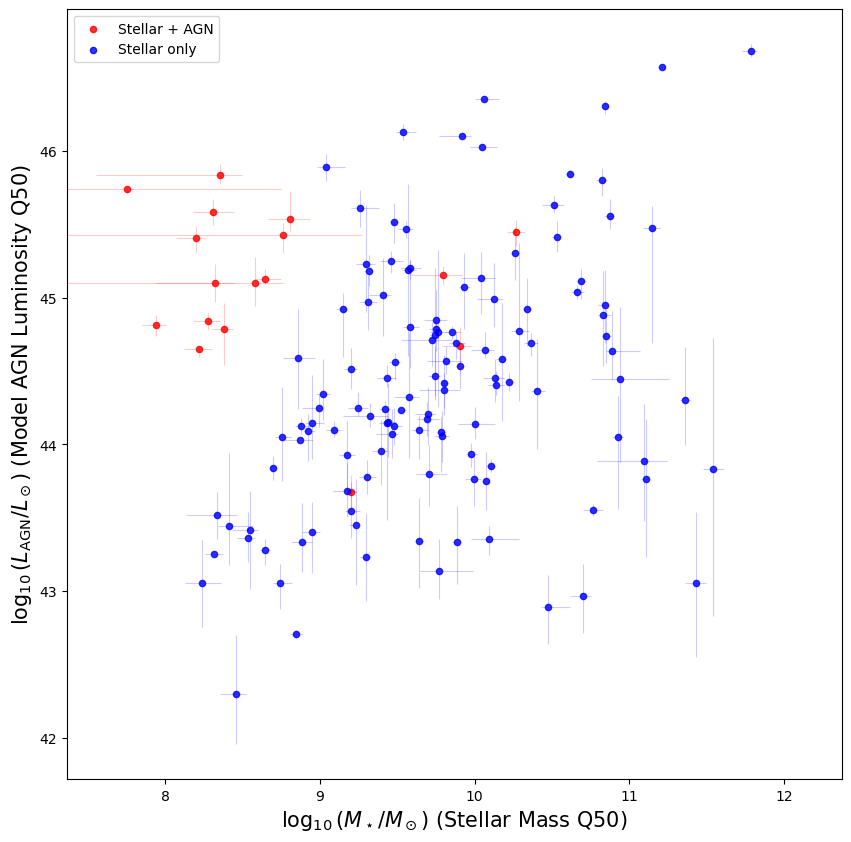

100%|██████████| 2000/2000 [00:03<00:00, 537.30it/s]



For plot below: 
Reduced chi squared = 0.585
Scatter from fit = 0.001
NMAD of normalised residuals = 0.274


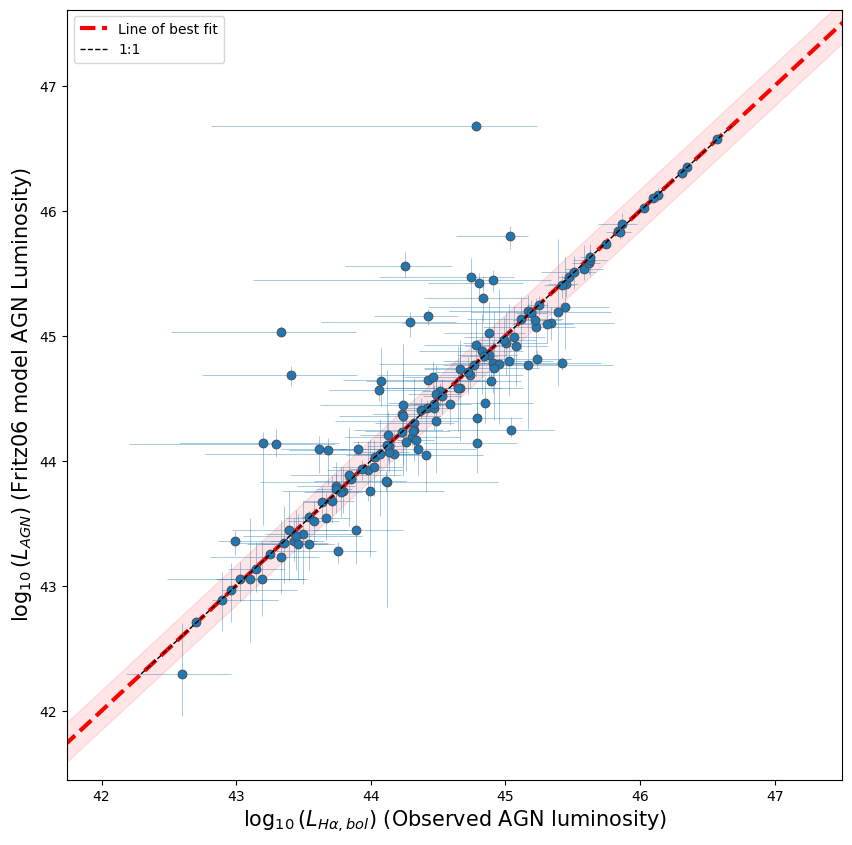

Line of best fit equation: 


<IPython.core.display.Math object>

For BIC filtered table: 
len of mask:  140


/tmp/ipykernel_1805362/52012199.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


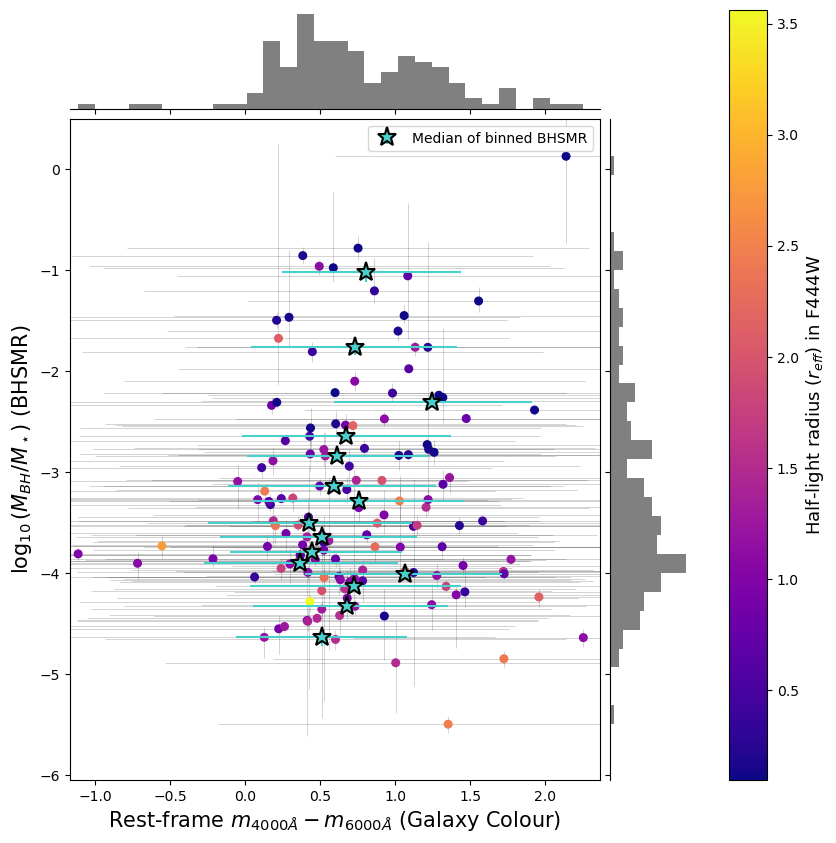

/tmp/ipykernel_1805362/1159714564.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


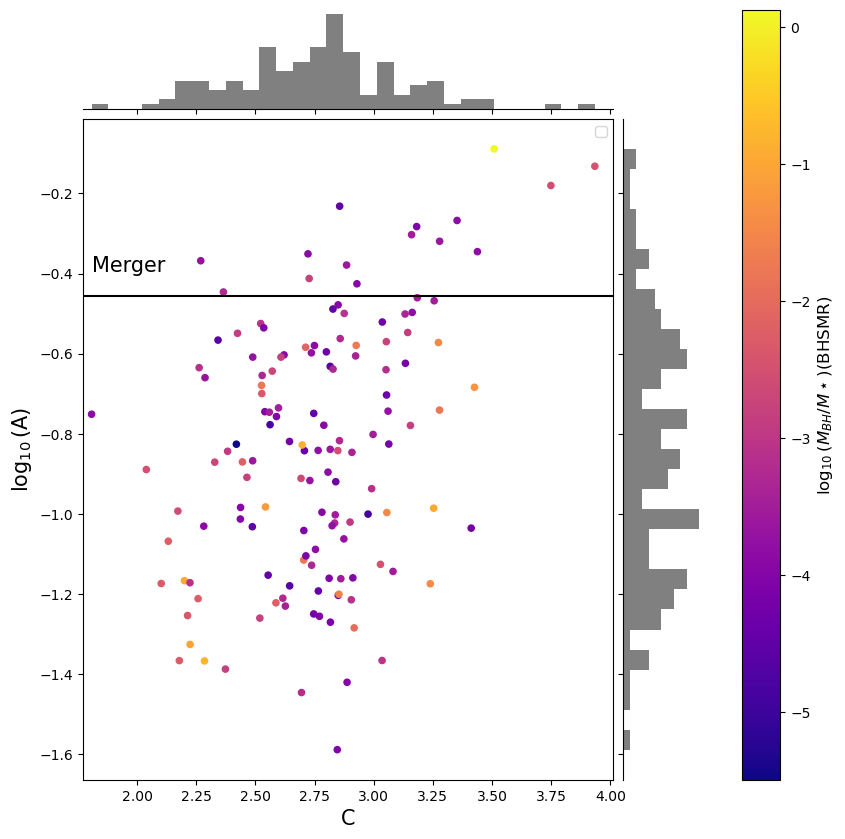

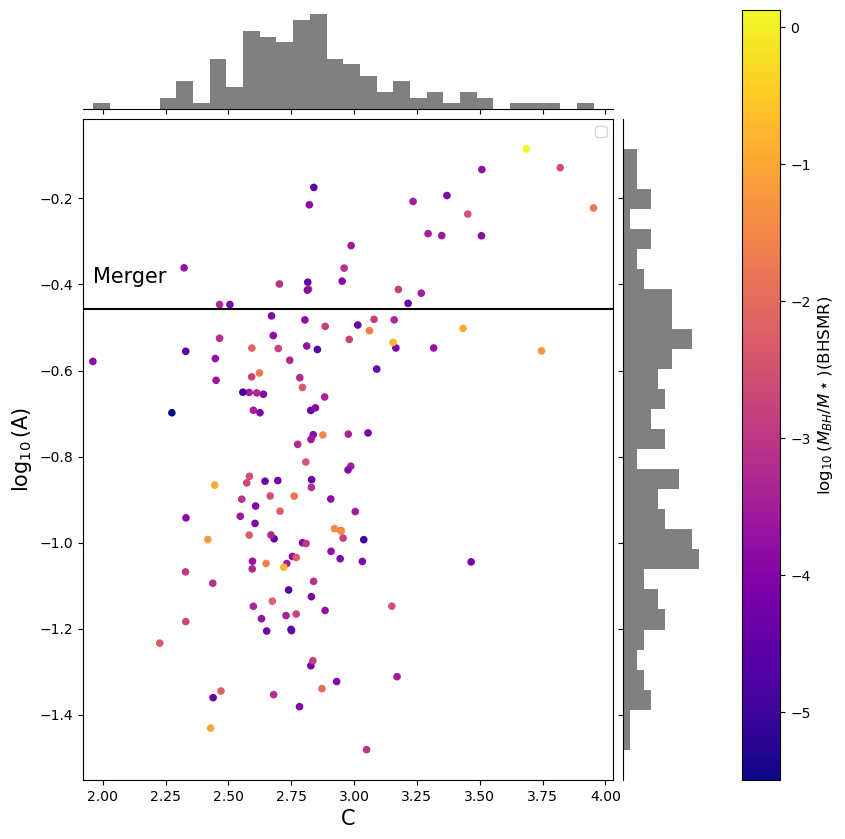

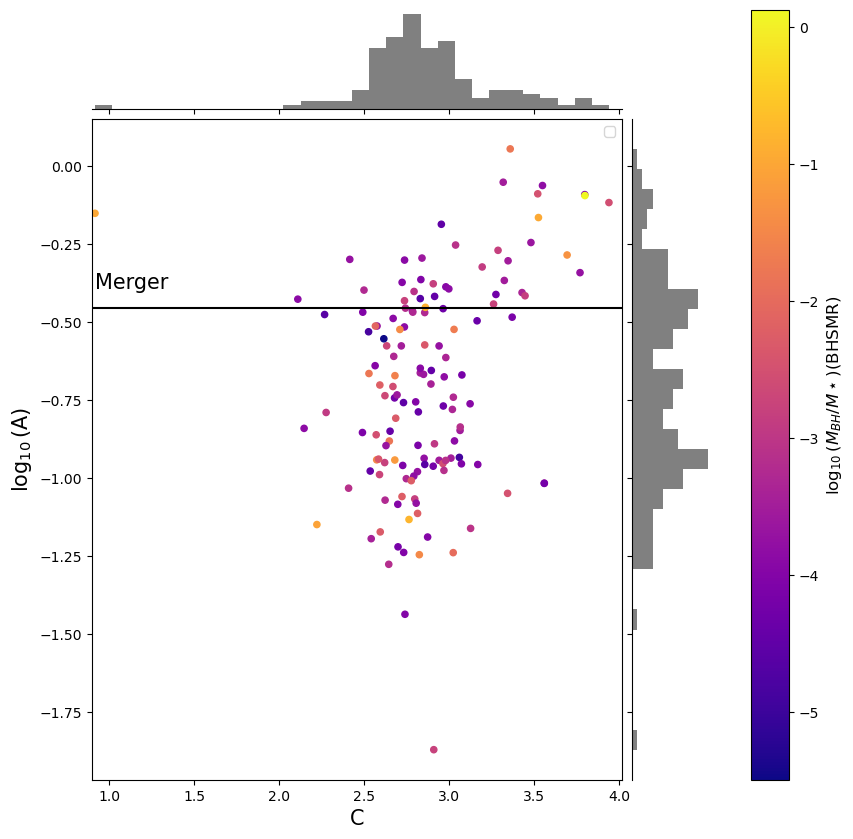

/tmp/ipykernel_1805362/3601617766.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


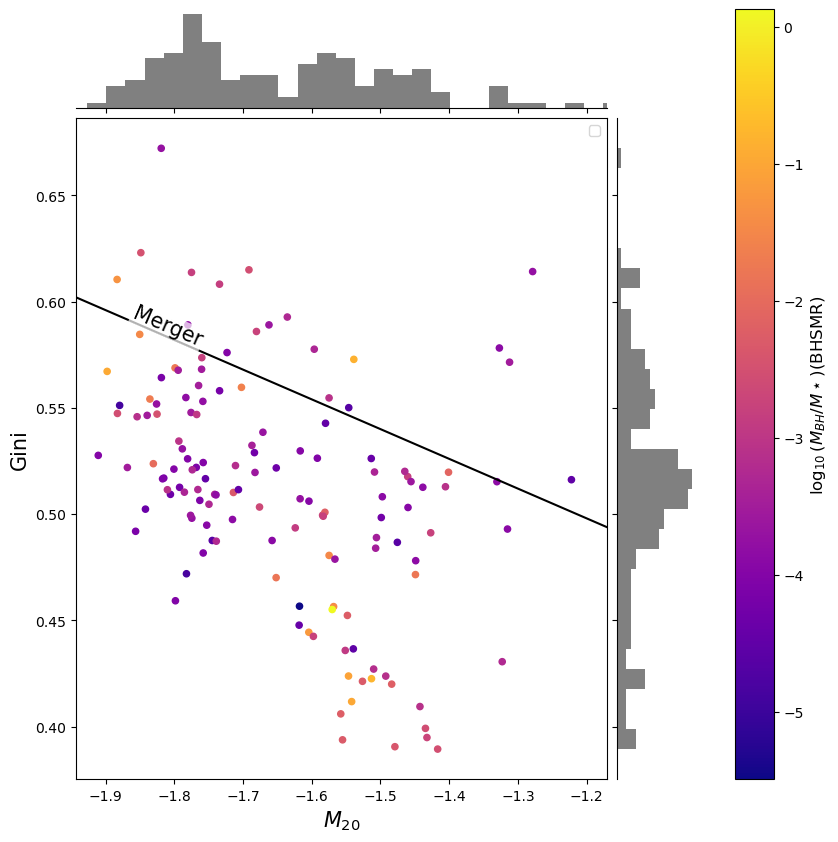

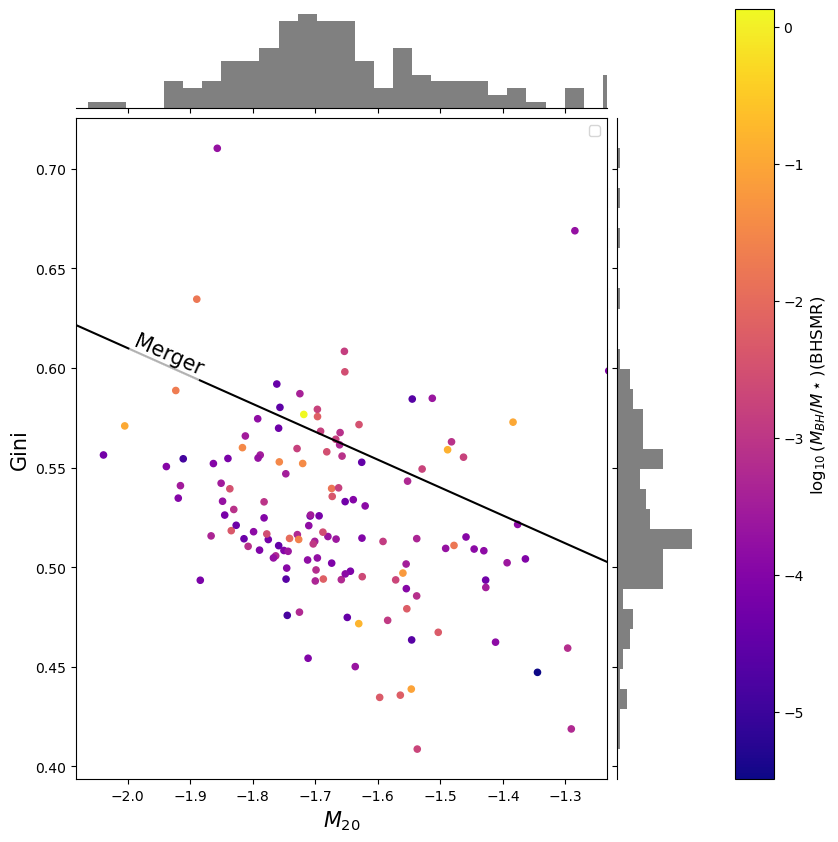

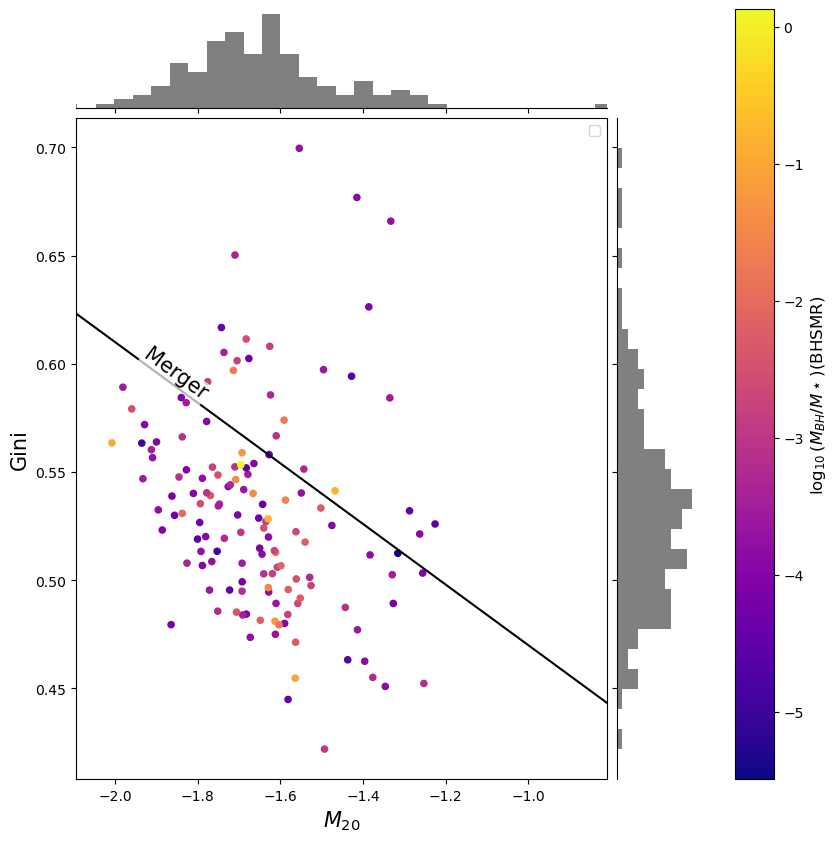

100%|██████████| 2000/2000 [00:03<00:00, 500.08it/s]



For plot below: 
Reduced chi squared = 95.7
Scatter from fit = 0.827
NMAD of normalised residuals = 0.997


<IPython.core.display.Math object>

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:03<00:00, 520.81it/s]


...

100%|██████████| 2000/2000 [00:03<00:00, 525.02it/s]



For plot below: 
Reduced chi squared = 137
Scatter from fit = 0.935
NMAD of normalised residuals = 0.832


<IPython.core.display.Math object>

<IPython.core.display.Math object>

/tmp/ipykernel_1805362/3214501326.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_r.legend(loc='upper right')


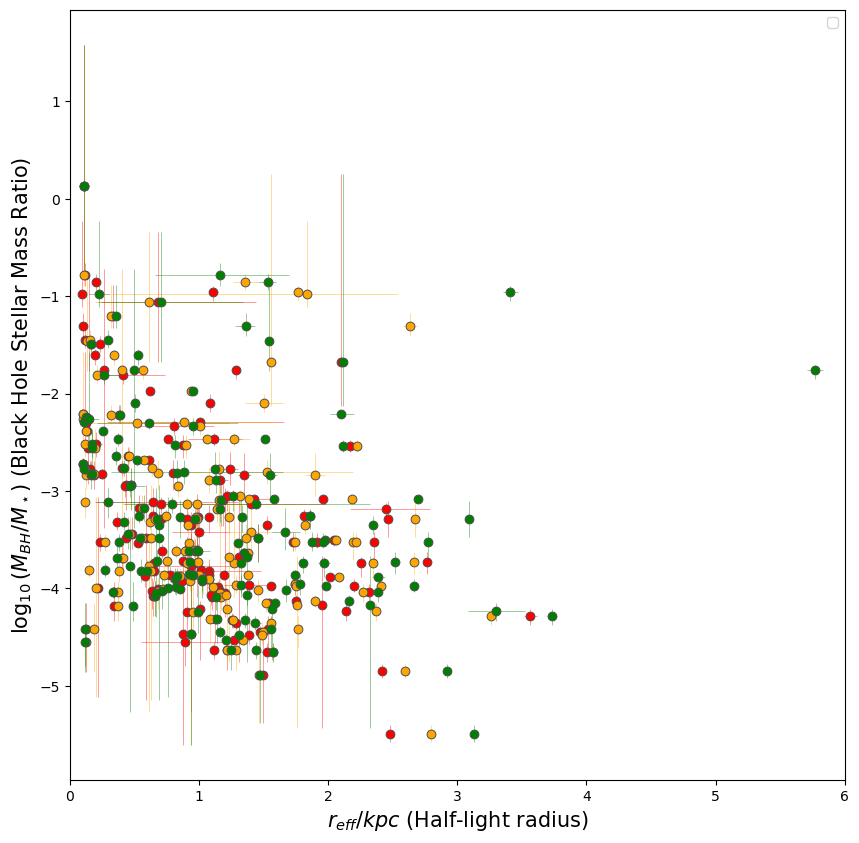

100%|██████████| 2000/2000 [00:03<00:00, 535.36it/s]



For plot below: 
Reduced chi squared = 136
Scatter from fit = 0.942
NMAD of normalised residuals = 0.816


<IPython.core.display.Math object>

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:03<00:00, 512.80it/s]


...

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 488.10it/s]



For plot below: 
Reduced chi squared = 143
Scatter from fit = 0.907
NMAD of normalised residuals = 0.811


<IPython.core.display.Math object>

<IPython.core.display.Math object>

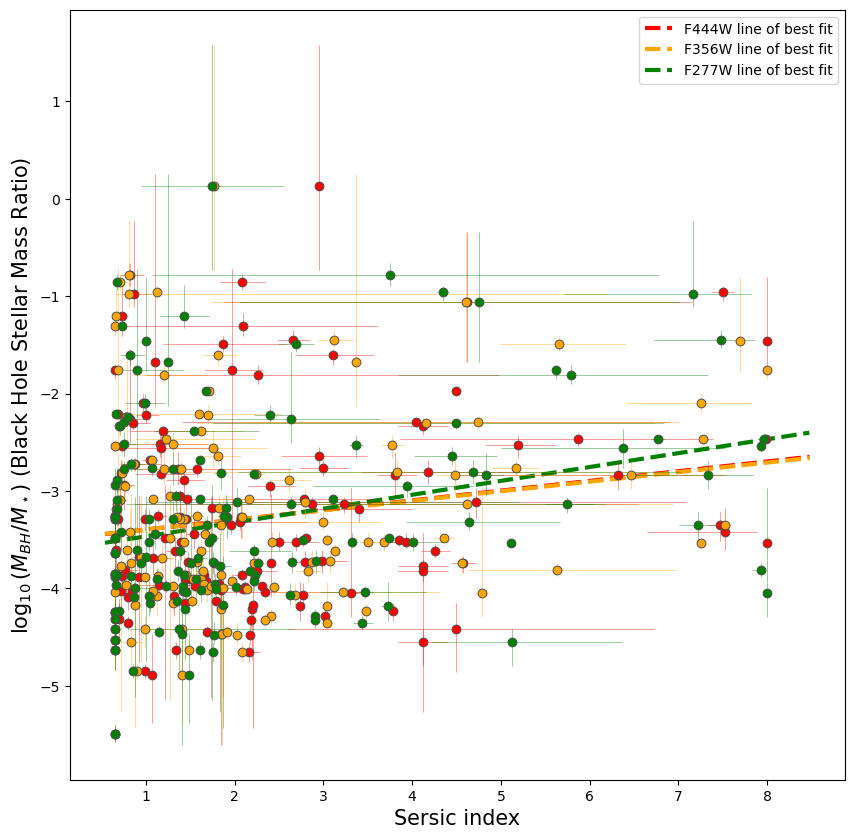

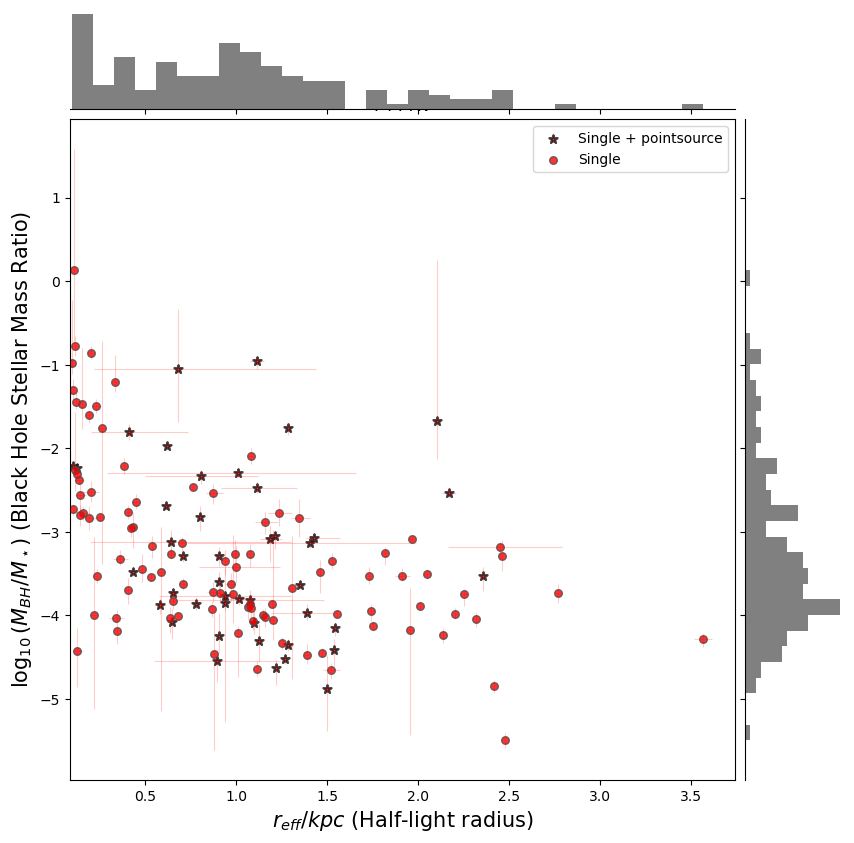

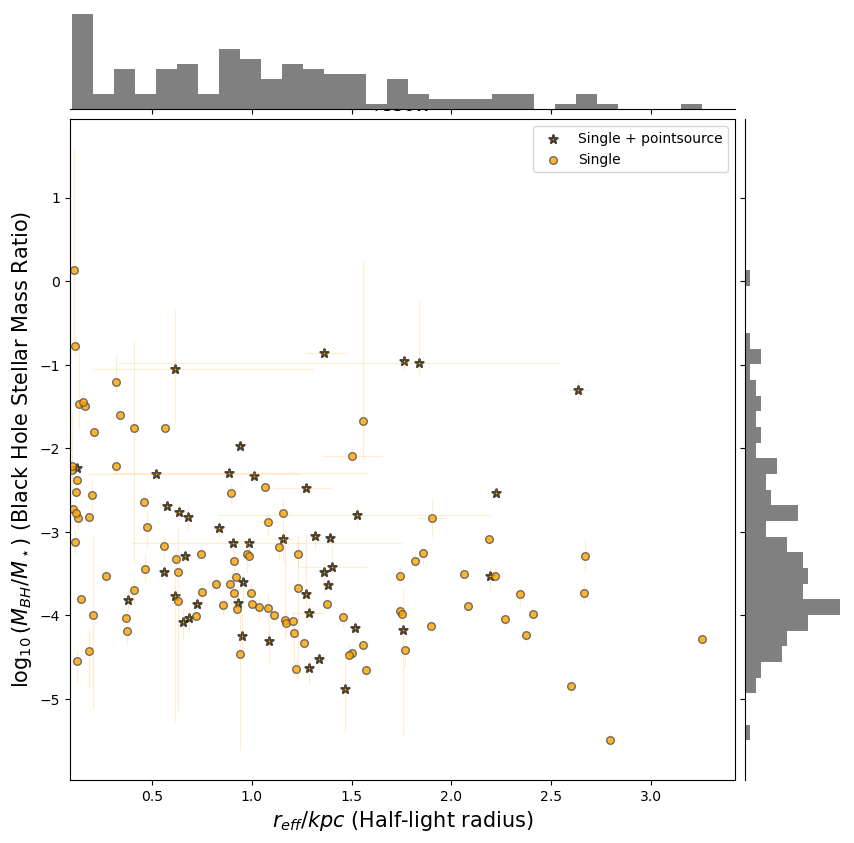

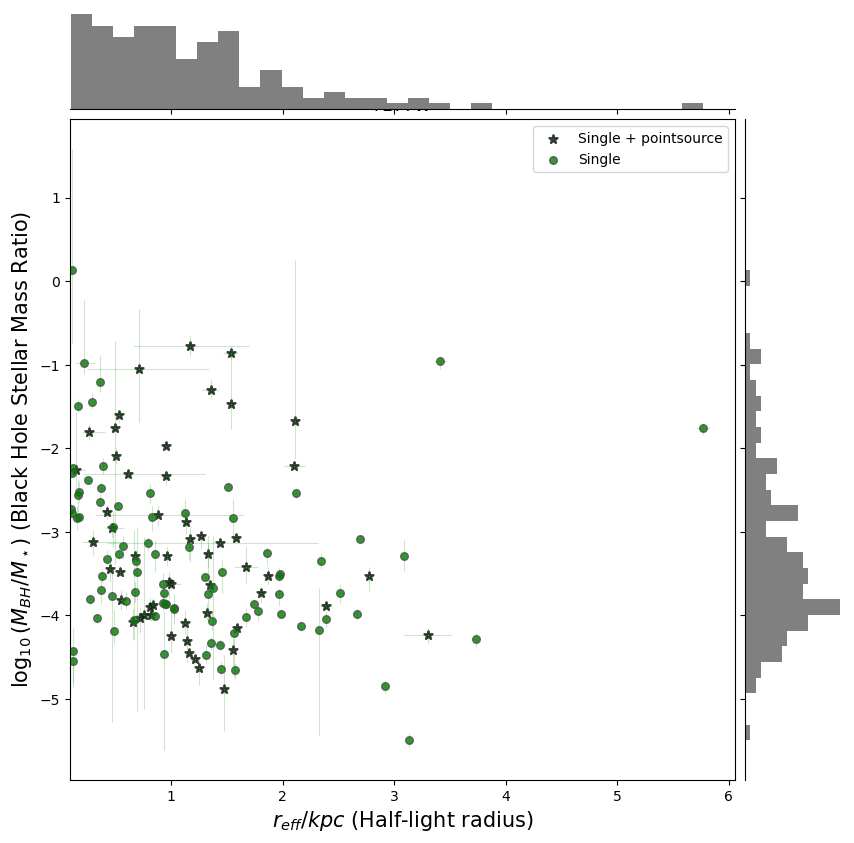

100%|██████████| 2000/2000 [00:04<00:00, 415.77it/s]



For plot below: 
Reduced chi squared = 136
Scatter from fit = 0.943
NMAD of normalised residuals = 0.818


<IPython.core.display.Math object>

<IPython.core.display.Math object>

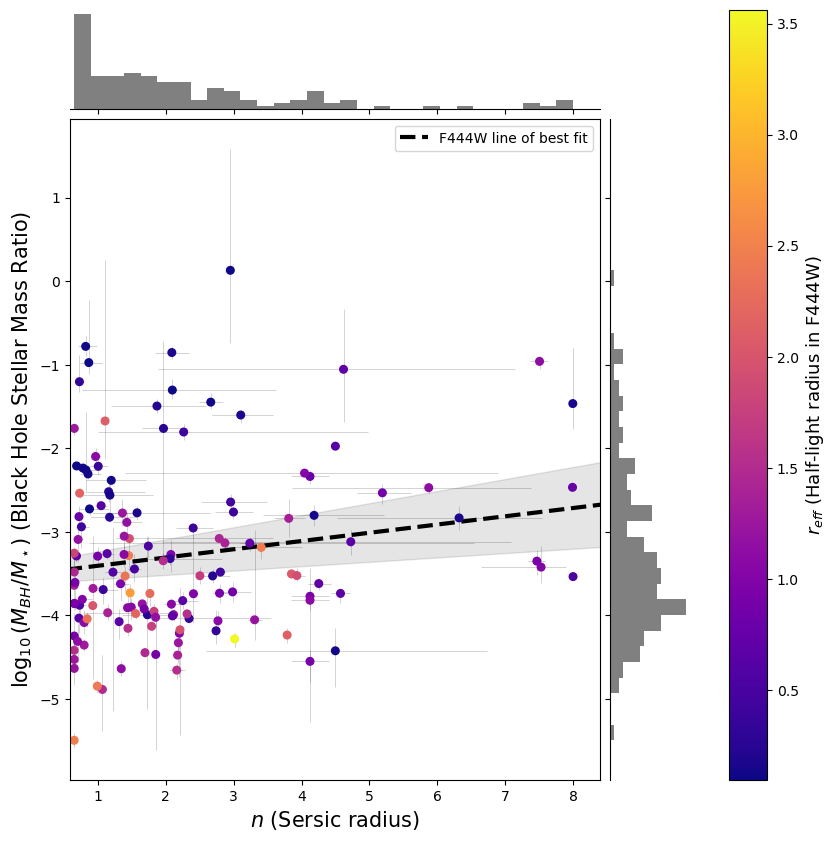

100%|██████████| 2000/2000 [00:04<00:00, 464.50it/s]


For plot below: 
Reduced chi squared = 139
Scatter from fit = 0.936
NMAD of normalised residuals = 0.827


<IPython.core.display.Math object>

<IPython.core.display.Math object>

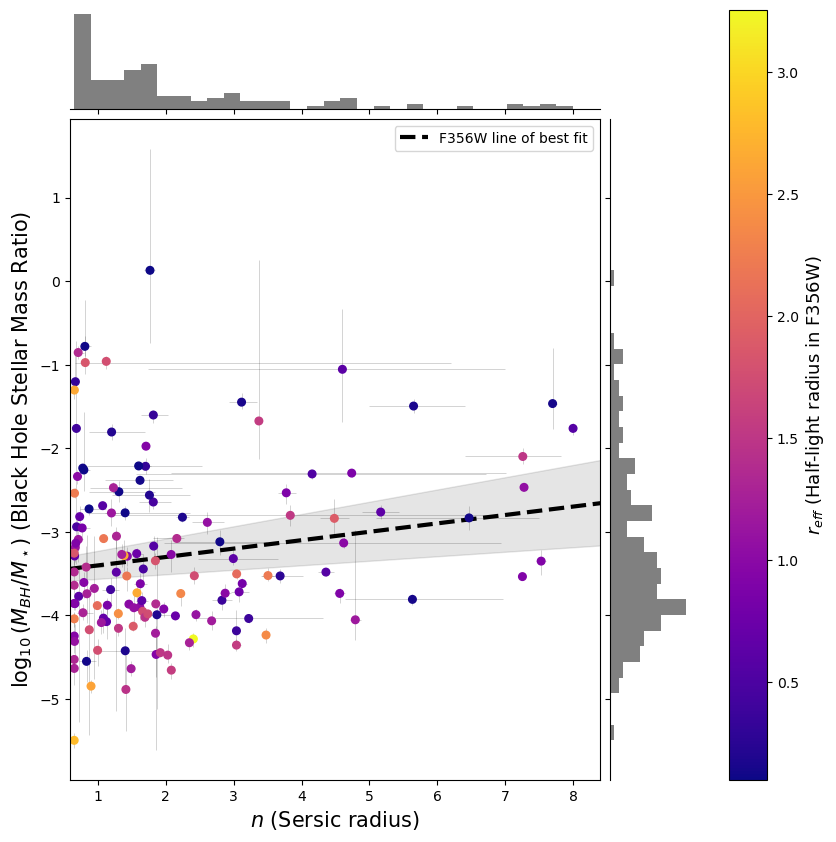

100%|██████████| 2000/2000 [00:04<00:00, 415.92it/s]


For plot below: 
Reduced chi squared = 143
Scatter from fit = 0.908
NMAD of normalised residuals = 0.811


<IPython.core.display.Math object>

<IPython.core.display.Math object>

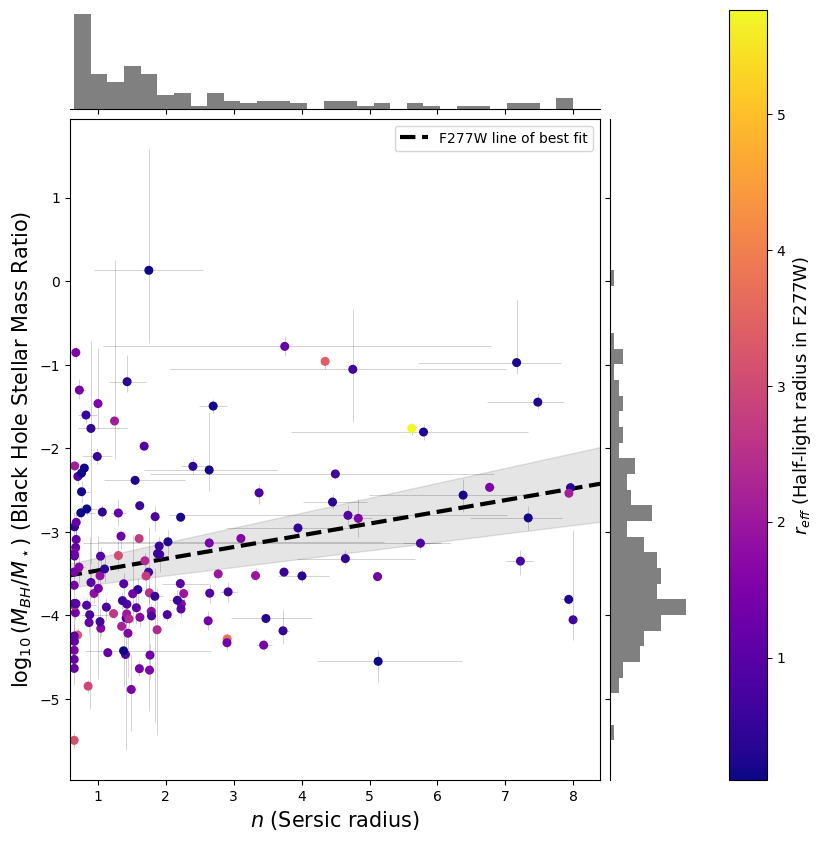

Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/Pysersic_results_3p0as/Single_sersic_fits_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    122   140R x 57C   [K, 21A, D, D, D, D, D, D, D, D, D, D, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, D, D, D, D, D, D]   
For single sersic fits only: 


100%|██████████| 2000/2000 [00:04<00:00, 402.37it/s]



For plot below: 
Reduced chi squared = 93.9
Scatter from fit = 0.819
NMAD of normalised residuals = 1.004


<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:05<00:00, 356.98it/s]



For plot below: 
Reduced chi squared = 127
Scatter from fit = 0.912
NMAD of normalised residuals = 0.884


<IPython.core.display.Math object>

<IPython.core.display.Math object>

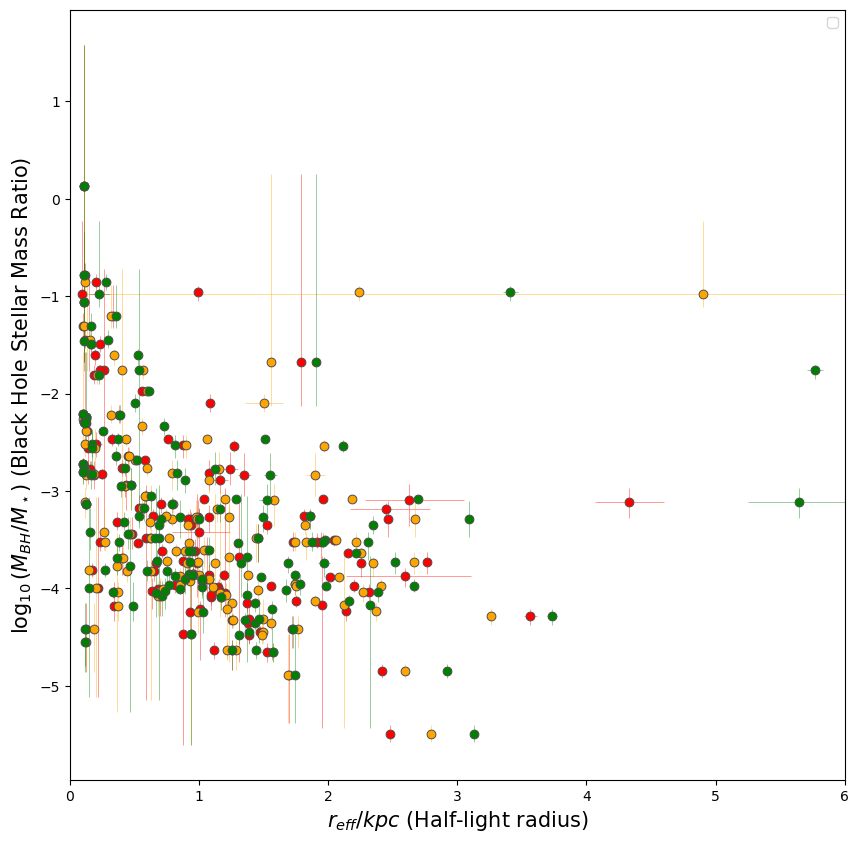

100%|██████████| 2000/2000 [00:05<00:00, 377.65it/s]



For plot below: 
Reduced chi squared = 141
Scatter from fit = 0.945
NMAD of normalised residuals = 0.838


<IPython.core.display.Math object>

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 454.53it/s]


...

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 480.99it/s]



For plot below: 
Reduced chi squared = 142
Scatter from fit = 0.902
NMAD of normalised residuals = 0.853


<IPython.core.display.Math object>

<IPython.core.display.Math object>

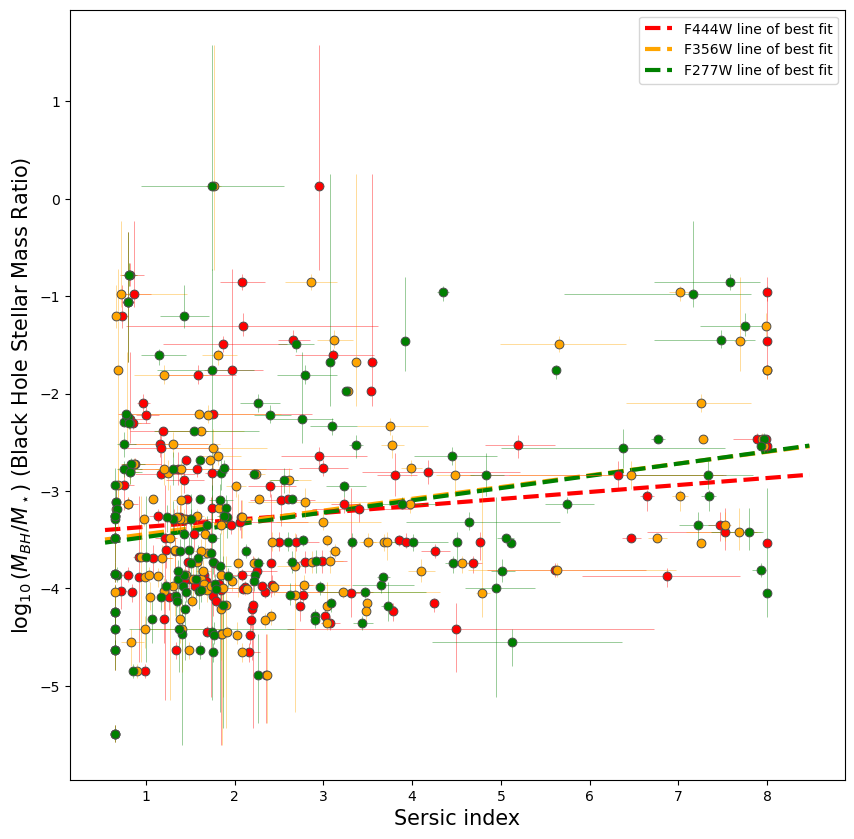

100%|██████████| 2000/2000 [00:04<00:00, 451.73it/s]


For plot below: 
Reduced chi squared = 141
Scatter from fit = 0.944
NMAD of normalised residuals = 0.836


<IPython.core.display.Math object>

<IPython.core.display.Math object>

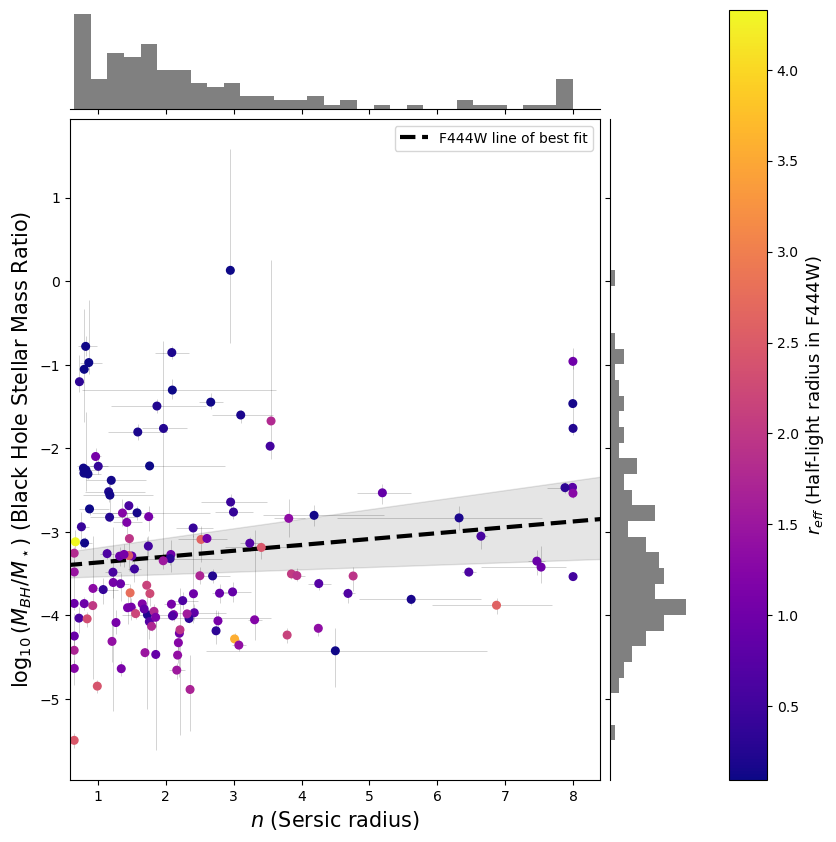

100%|██████████| 2000/2000 [00:04<00:00, 492.41it/s]


For plot below: 
Reduced chi squared = 133
Scatter from fit = 0.917
NMAD of normalised residuals = 0.804


<IPython.core.display.Math object>

<IPython.core.display.Math object>

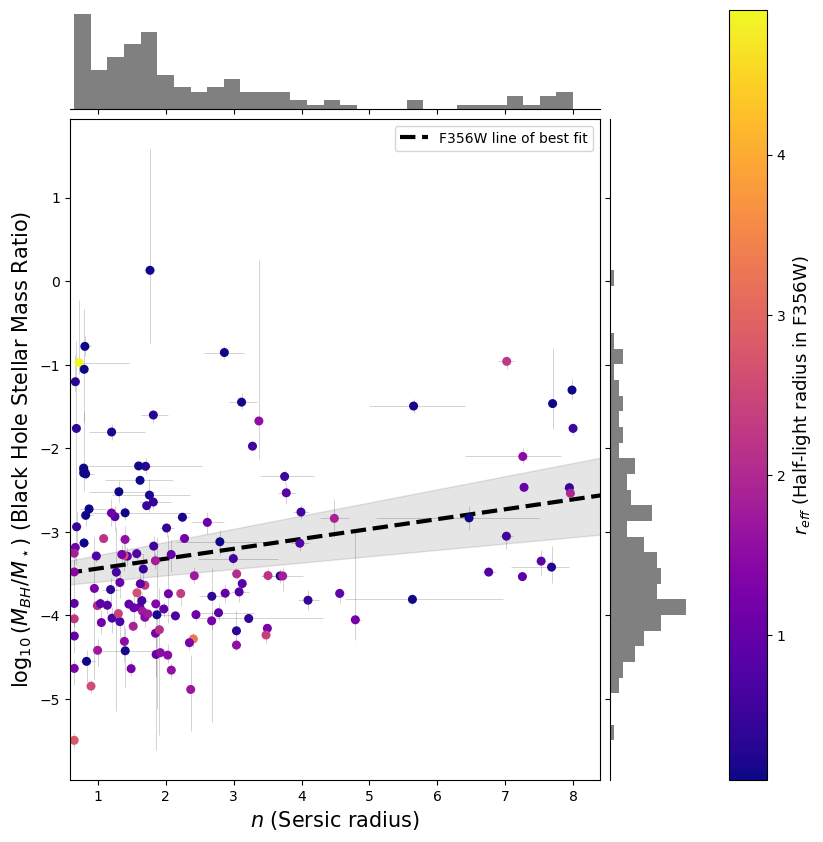

100%|██████████| 2000/2000 [00:04<00:00, 456.68it/s]


For plot below: 
Reduced chi squared = 142
Scatter from fit = 0.908
NMAD of normalised residuals = 0.856


<IPython.core.display.Math object>

<IPython.core.display.Math object>

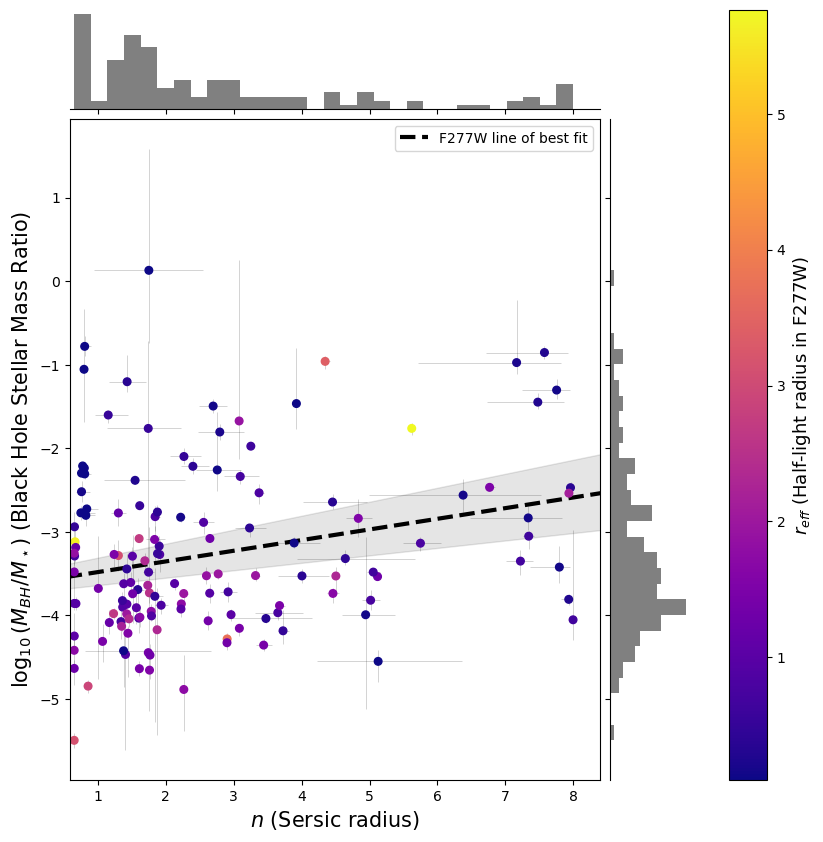

Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/Pysersic_results_0p96as/PS_single_sersic_NEW_fits_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    122   140R x 57C   [K, 21A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
For single+PS fits only: 


100%|██████████| 2000/2000 [00:04<00:00, 490.20it/s]



For plot below: 
Reduced chi squared = 119
Scatter from fit = 0.844
NMAD of normalised residuals = 0.982


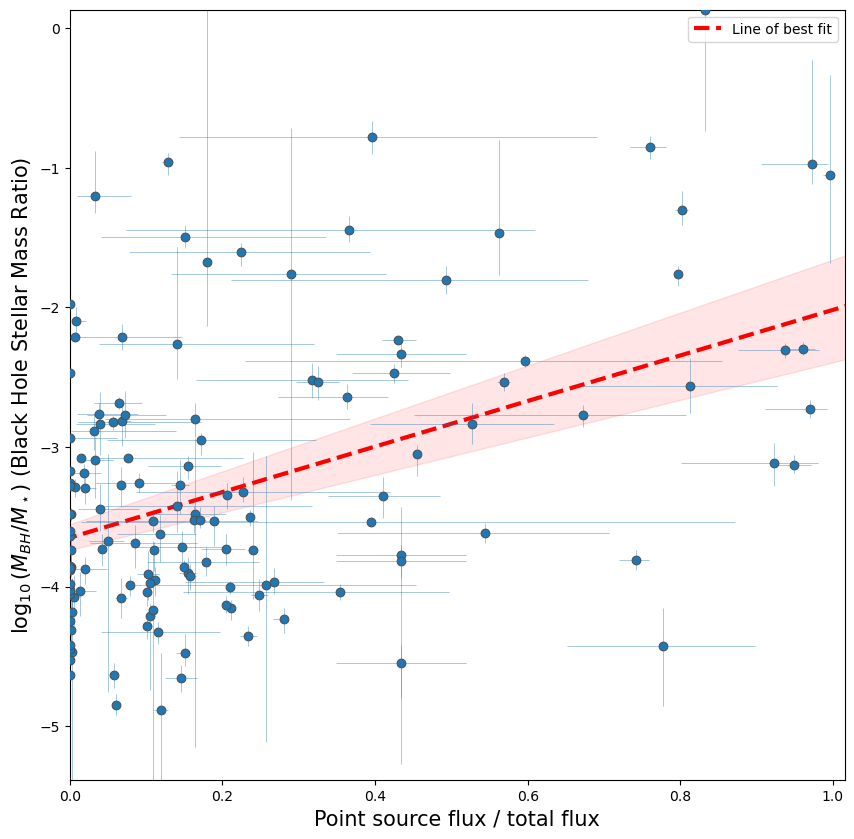

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 475.30it/s]



For plot below: 
Reduced chi squared = 96.2
Scatter from fit = 0.860
NMAD of normalised residuals = 0.793


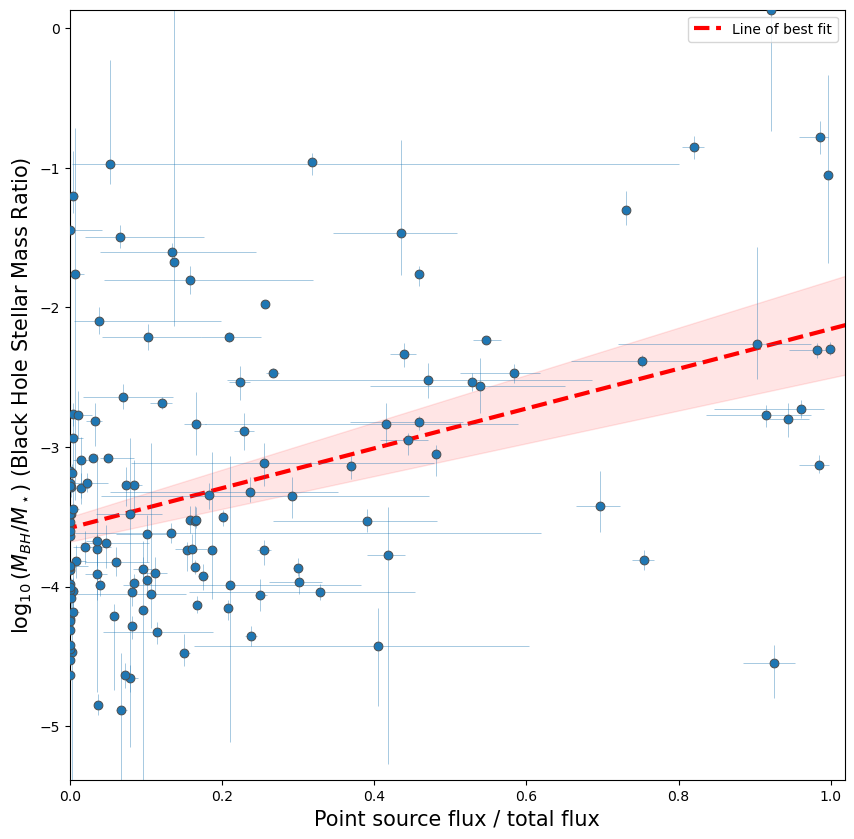

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 492.47it/s]



For plot below: 
Reduced chi squared = 94.1
Scatter from fit = 0.861
NMAD of normalised residuals = 0.845


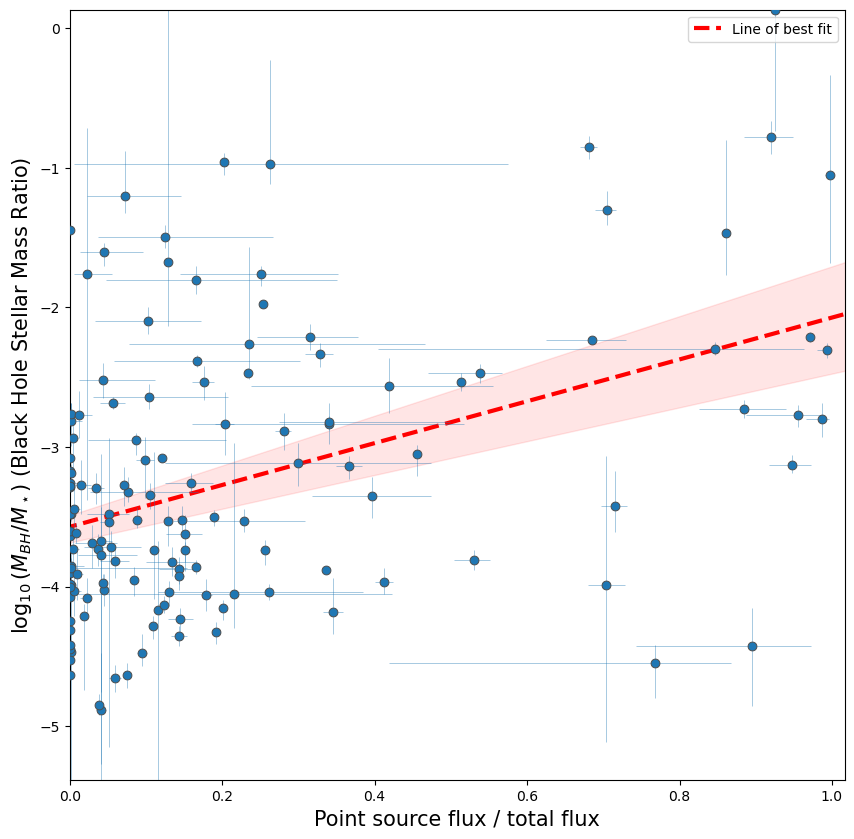

Line of best fit equation: 


<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 461.41it/s]



For plot below: 
Reduced chi squared = 95.3
Scatter from fit = 0.892
NMAD of normalised residuals = 0.922


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 485.30it/s]



For plot below: 
Reduced chi squared = 132
Scatter from fit = 0.940
NMAD of normalised residuals = 0.857


<IPython.core.display.Math object>

<IPython.core.display.Math object>

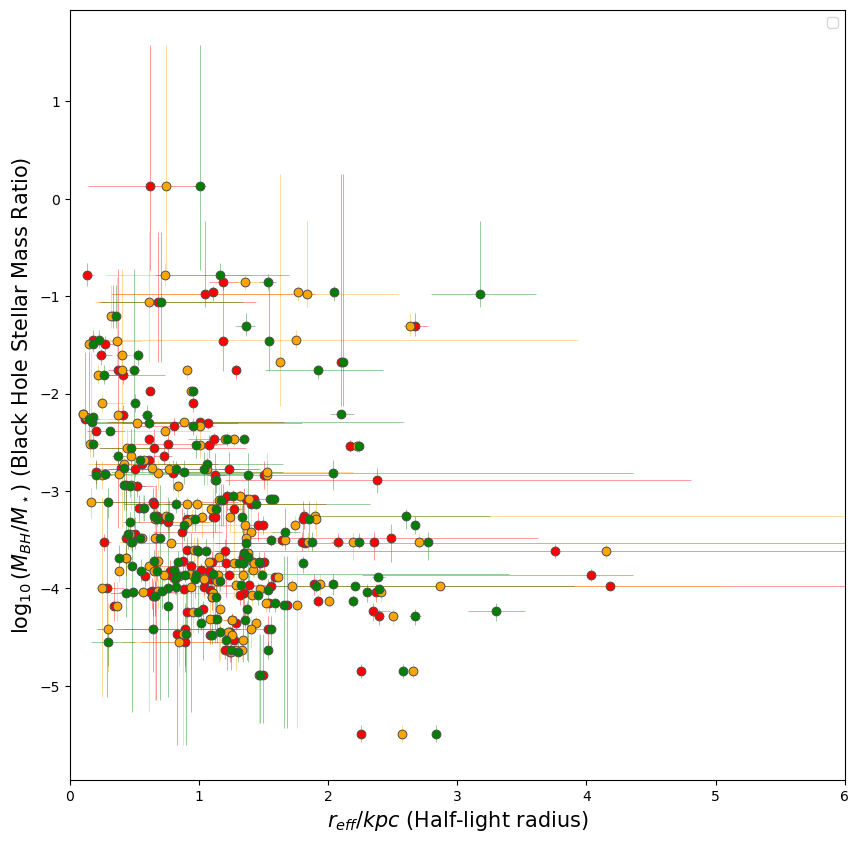

100%|██████████| 2000/2000 [00:04<00:00, 468.56it/s]



For plot below: 
Reduced chi squared = 105
Scatter from fit = 0.892
NMAD of normalised residuals = 0.830


<IPython.core.display.Math object>

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 420.80it/s]


...

<IPython.core.display.Math object>

100%|██████████| 2000/2000 [00:04<00:00, 471.03it/s]



For plot below: 
Reduced chi squared = 139
Scatter from fit = 0.926
NMAD of normalised residuals = 0.783


<IPython.core.display.Math object>

<IPython.core.display.Math object>

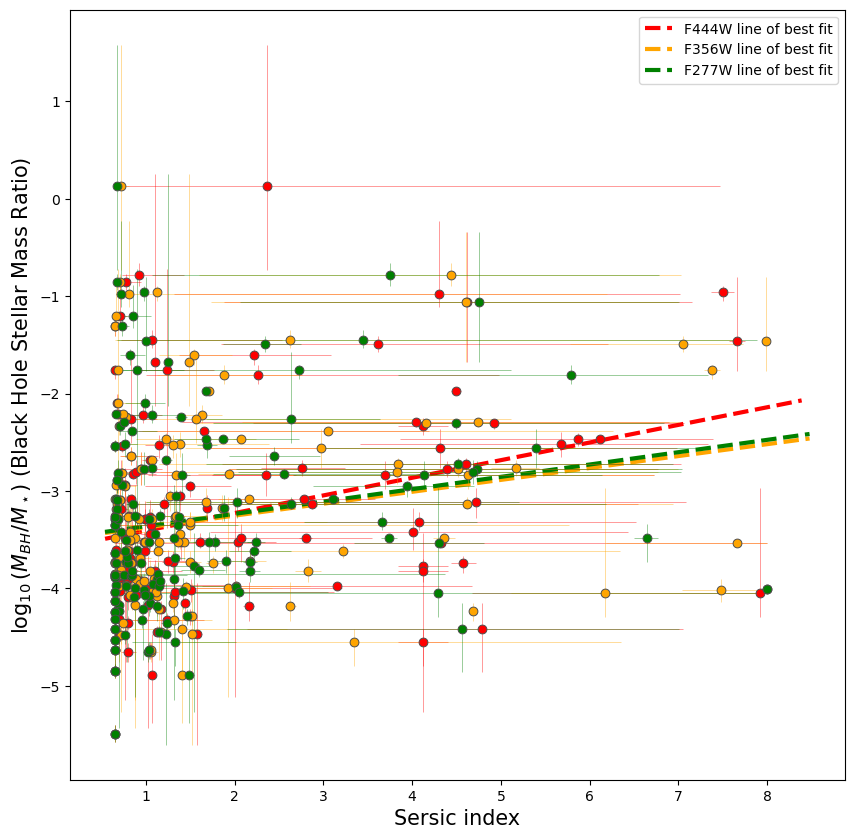

/tmp/ipykernel_1805362/7072447.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_r.legend(loc='upper right')


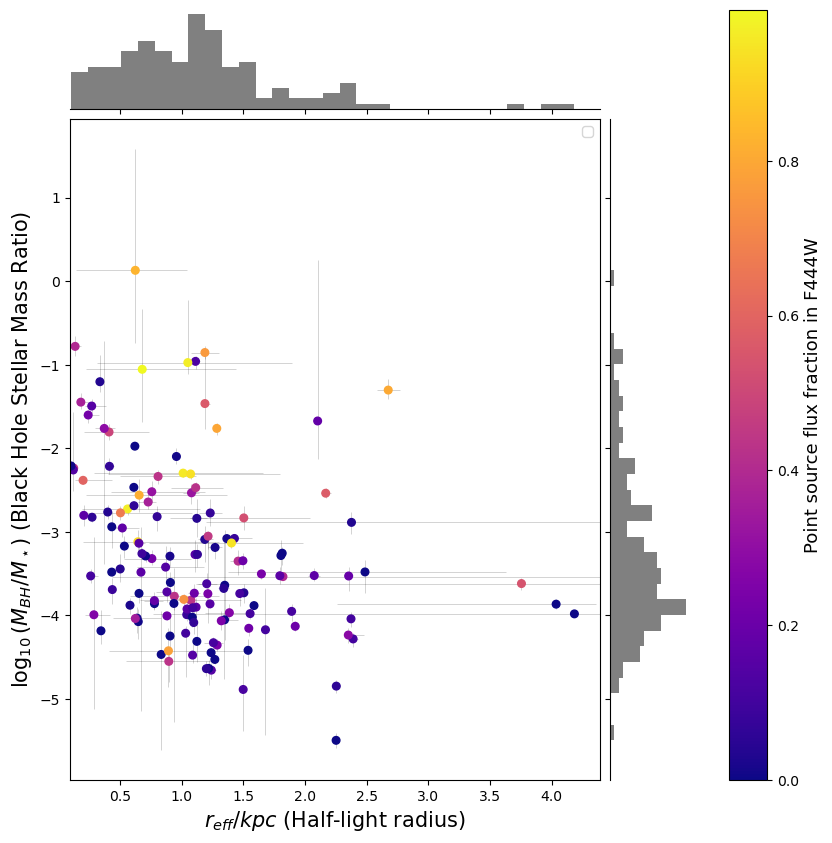

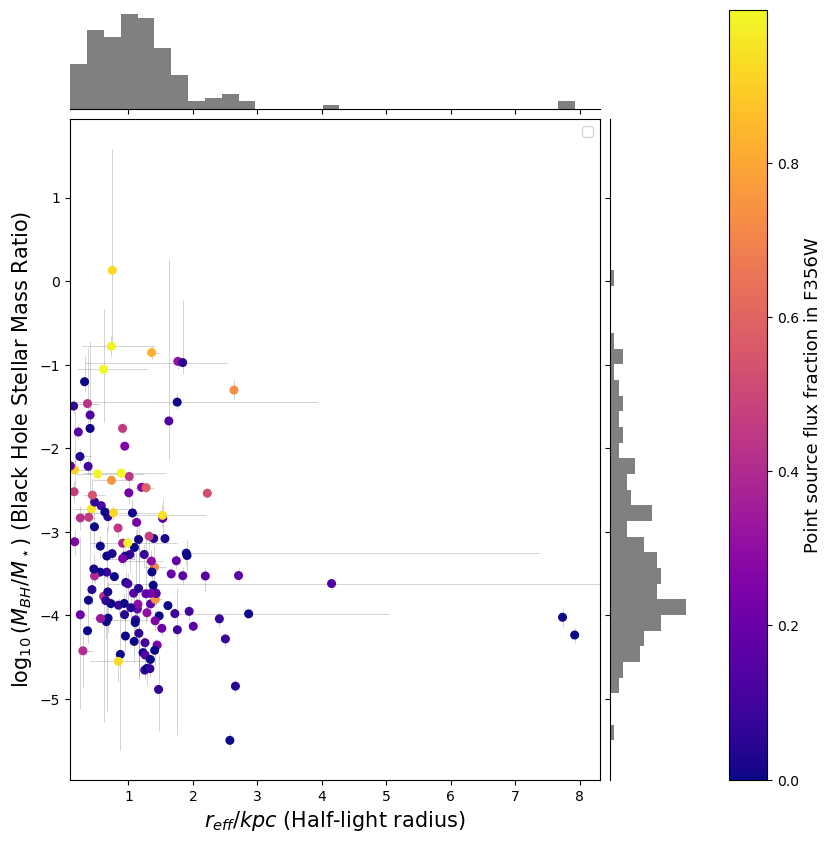

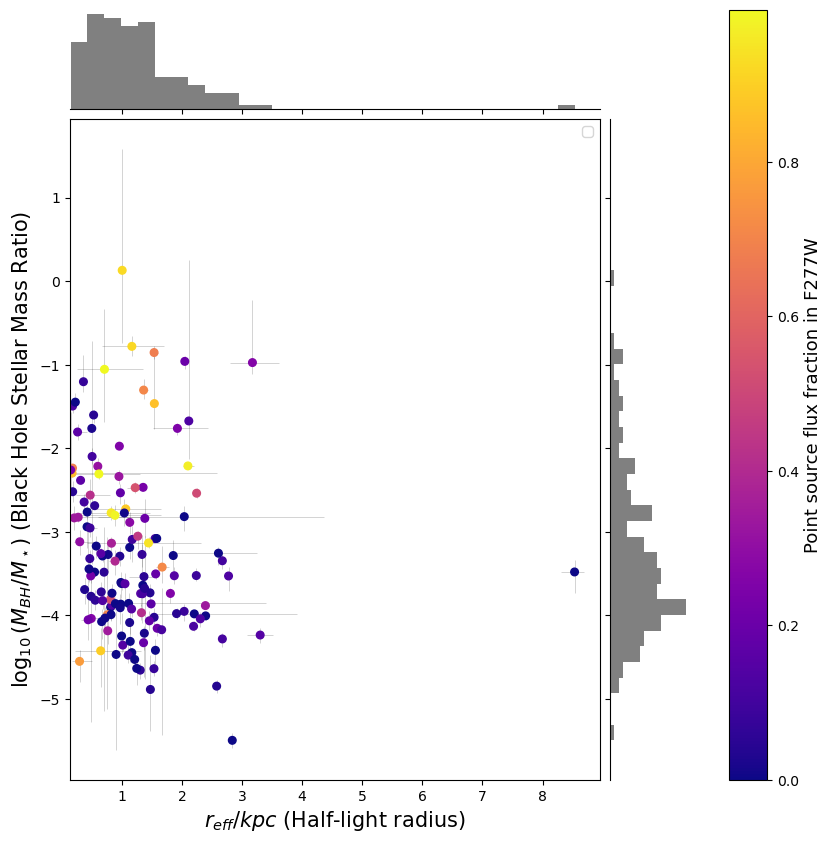

100%|██████████| 2000/2000 [00:04<00:00, 478.11it/s]


For plot below: 
Reduced chi squared = 105
Scatter from fit = 0.892
NMAD of normalised residuals = 0.834


<IPython.core.display.Math object>

<IPython.core.display.Math object>

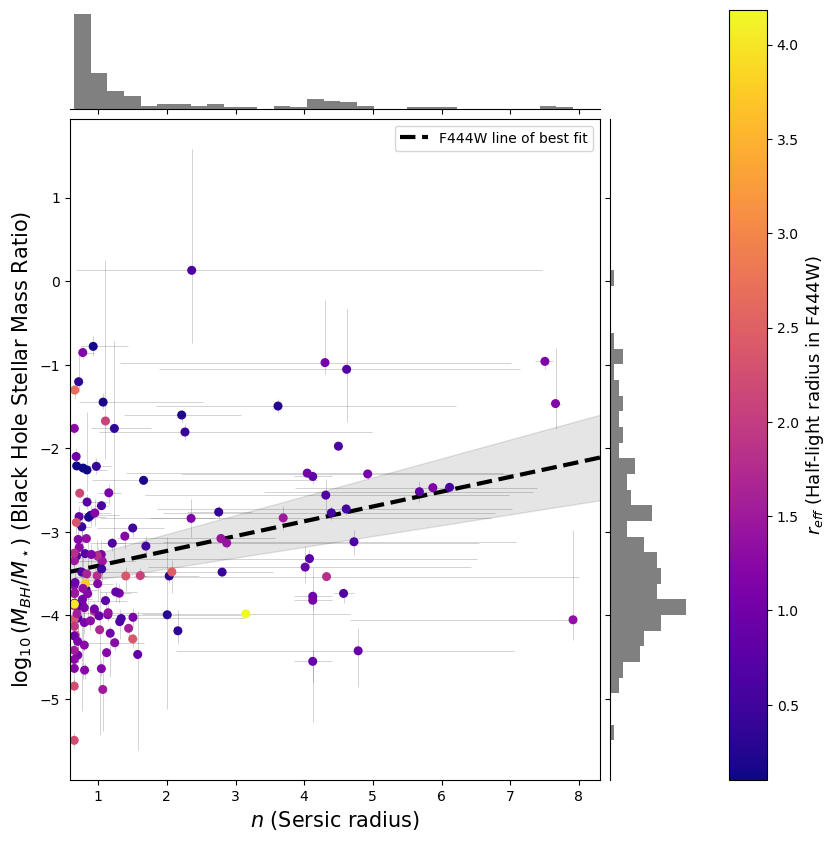

100%|██████████| 2000/2000 [00:04<00:00, 422.25it/s]


For plot below: 
Reduced chi squared = 137
Scatter from fit = 0.921
NMAD of normalised residuals = 0.866


<IPython.core.display.Math object>

<IPython.core.display.Math object>

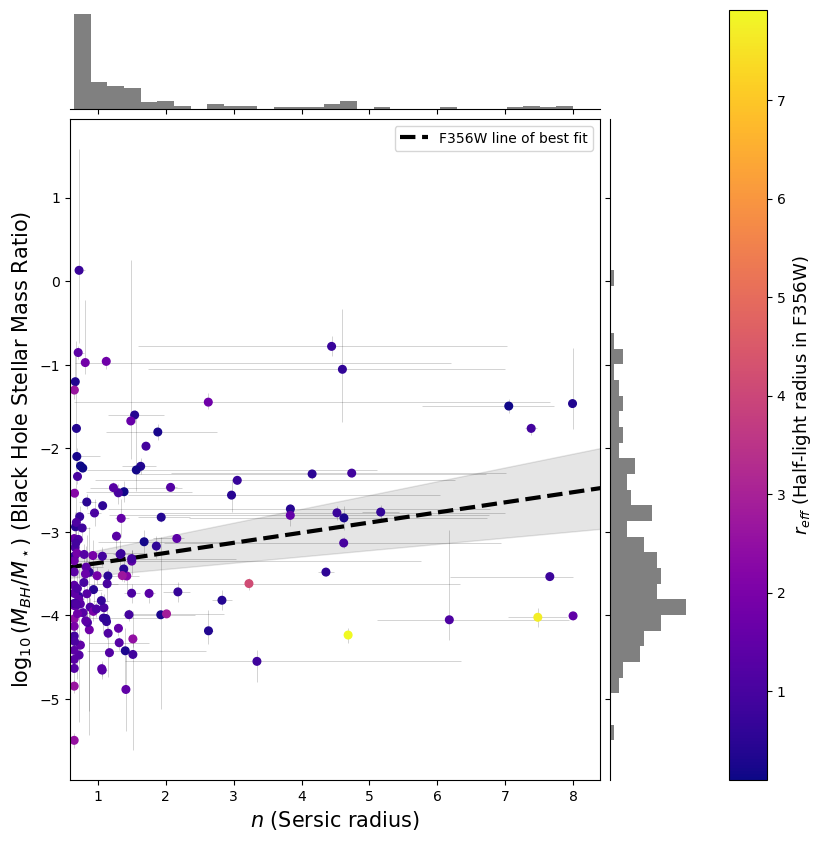

100%|██████████| 2000/2000 [00:03<00:00, 512.45it/s]


For plot below: 
Reduced chi squared = 139
Scatter from fit = 0.926
NMAD of normalised residuals = 0.784


<IPython.core.display.Math object>

<IPython.core.display.Math object>

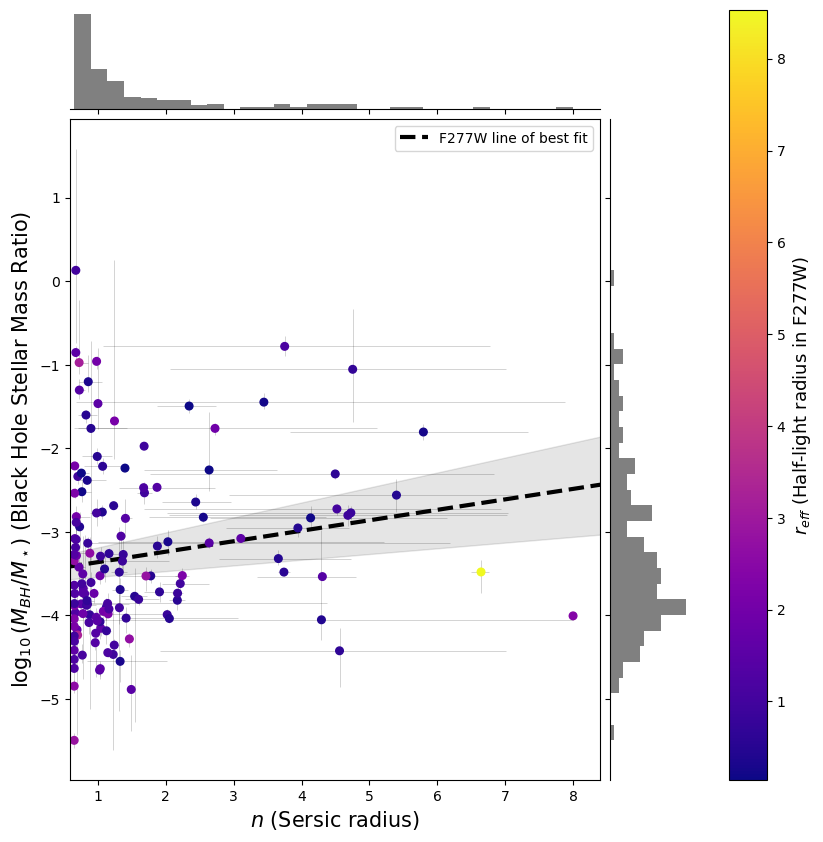

In [1599]:
if __name__ == "__main__":
    
    SED_tab = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/Final_filtered_all_galaxies_SED_table.fits")
    
    plot_AGNlum(SED_tab)

    # time_evolution_SED_data(SED_tab)

    morphology_tab = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/csv_tables/All_morphology_table.csv")

    morphology_and_galaxy_table = join(
                SED_tab,
                morphology_tab,
                keys=["SURVEY_ID", "REDSHIFT"]
    )

    print("For BIC filtered table: ")

    plot_galaxy_colours(morphology_and_galaxy_table)

    log_A_vs_C(morphology_and_galaxy_table)

    gini_vs_M20(morphology_and_galaxy_table)

    stacked_bhsmr_vs_morph(morphology_and_galaxy_table)

    individual_plots_bhsmr_vs_r_eff_filtered_morph(morphology_and_galaxy_table)

    individual_plots_bhsmr_vs_n(morphology_and_galaxy_table)

    # time_evolution_morphology(morphology_and_galaxy_table)

    #--------------------------------------------------------------------------------------------------------------
    single_morph_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/Pysersic_results_3p0as/Single_sersic_fits_table.fits")

    single_morph_galaxy_table = join(
            SED_tab,
            single_morph_table,
            keys=["SURVEY_ID", "SURVEY", "REDSHIFT"]
    )

    print("For single sersic fits only: ")

    # bhm_vs_morph(single_morph_galaxy_table) needs a mask for 0 errs

    stacked_bhsmr_vs_morph(single_morph_galaxy_table)

    individual_plots_bhsmr_vs_n(single_morph_galaxy_table)

    
    #--------------------------------------------------------------------------------------------------------------

    PS_single_morph_table = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/Pysersic_results_0p96as/PS_single_sersic_NEW_fits_table.fits")

    PS_single_morph_galaxy_table = join(
                SED_tab,
                PS_single_morph_table,
                keys=["SURVEY_ID", "SURVEY", "REDSHIFT"]
        )

    print("For single+PS fits only: ")

    plot_bhsmr_vs_flux(PS_single_morph_galaxy_table)

    stacked_bhsmr_vs_morph(PS_single_morph_galaxy_table)

    individual_plots_bhsmr_vs_r_eff(PS_single_morph_galaxy_table)

    individual_plots_bhsmr_vs_n(PS_single_morph_galaxy_table)

    #---------------------------------------------------------------------------------------------------------------------------------------
    